# Laboratorio 1 – Exploración, preparación y regresión lineal

**Curso:** ISIS-2611 – Aprendizaje de Máquina  

**Caso:** AlpesPlanck  

**Autores:** Lucas Valbuena 202311538 y Juan Goyeneche 202320863

**Semestre:** 2026-02


## 0. Configuración del entorno


### 0.1 Importación de librerías 

*Se importaron las librerías necesarias para manipulación, visualización y modelado.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### 0.2 Configuración global de consideraciones


In [2]:
random_state = 42
np.random.seed(random_state)

test_size = 0.25

### 0.3 Carga de los datos


*Se cargaron los datos de entrenamiento desde la carpeta `data/`. El archivo de test se cargará posteriormente, cuando se haya seleccionado el mejor modelo.*

In [3]:
datos_entrenamiento = pd.read_csv("data/Datos Lab 1.csv")
data = datos_entrenamiento.copy()

## 1. Entendimiento del negocio y de los datos


### 1.1 Descripción del caso y objetivo del modelo


*El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas en su estación de Jena, Alemania. El objetivo del laboratorio fue explorar estos datos y preparar un modelo de regresión lineal para predecir la temperatura máxima del día siguiente, de manera que la información pudiera apoyar la prevención de riesgos como incendios forestales y los efectos asociados con El Niño y La Niña.*

### 1.2 Revisión del diccionario de datos


In [4]:
diccionario_datos = pd.read_excel("data/Diccionario de datos.xlsx")
display(diccionario_datos)

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


*Mediante la función `display` se mostró el diccionario de variables. Luego, se procedió a categorizar las variables según sus tipos: categóricas, numéricas continuas y numéricas discretas.*

In [5]:
variables_categoricas = diccionario_datos.loc[
    diccionario_datos["tipo"] == "texto", "variable"
].tolist()

variables_numericas = diccionario_datos.loc[
    diccionario_datos["tipo"] == "numérico", "variable"
].tolist()
variables_numericas_discretas = [
    "registros_del_dia",
    "anio",
    "dia_del_anio",
]
variables_numericas_continuas = [
    variable
    for variable in variables_numericas
    if variable not in variables_numericas_discretas
]

print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Variables numéricas continuas: {len(variables_numericas_continuas)}")
print(f"Variables numéricas discretas: {len(variables_numericas_discretas)}")

Variables categóricas: 4
Variables numéricas continuas: 20
Variables numéricas discretas: 3


### 1.3 Definición de la variable objetivo (temperatura máxima del día)


*Se definió explícitamente la temperatura máxima del día como variable objetivo.*

In [6]:
variable_objetivo = "temp_max_manana"

## 2. Exploración de los datos 


### 2.1 Estructura general del dataset


*Se revisaron las dimensiones, los tipos, las primeras filas y la información general del dataset.*

In [7]:
print("Dimensiones del dataset:")
print(f"Filas: {datos_entrenamiento.shape[0]}, Columnas: {datos_entrenamiento.shape[1]}")

print("\nPrimeras cinco filas:")
display(datos_entrenamiento.head())

Dimensiones del dataset:
Filas: 2576, Columnas: 27

Primeras cinco filas:


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


*No se incluyeron nuevamente las funciones `dtypes` e `info` porque los tipos de variables y la información general ya fueron mostrados en el diccionario de datos. De esta manera, se evitó repetir información y se conservaron en esta sección únicamente las revisiones adicionales de estructura.*

### 2.2 Estadísticas descriptivas


*Se resumieron las variables con estadísticas descriptivas apropiadas.*

In [8]:
print("Estadísticas descriptivas:")
display(datos_entrenamiento.describe(include="all").T)

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2009-01-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


*Los valores `25%`, `50%` y `75%` corresponden a los cuartiles de las variables numéricas. El primer cuartil (`25%`) indica que aproximadamente el 25% de los datos tiene un valor menor o igual a ese punto. El segundo cuartil (`50%`) es la mediana, es decir, divide los datos en dos partes iguales. El tercer cuartil (`75%`) indica que aproximadamente el 75% de los datos tiene un valor menor o igual a ese punto. En las variables categóricas, `freq` representa cuántas veces aparece la categoría más frecuente, no un porcentaje.*

## 3. Calidad de los datos

| Dimensión | Pregunta que responde |
|---|---|
| Completitud | ¿Faltan datos? |
| Unicidad | ¿Hay registros duplicados? |
| Consistencia | ¿Los valores del mismo concepto están representados de forma uniforme? |
| Validez | ¿Los valores están dentro del rango permitido y tienen sentido en el contexto? |

### 3.1 Completitud

*Se revisó la presencia de datos faltantes en las variables del conjunto.*

In [9]:
((data.isnull().sum() / data.shape[0])).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64

*Se observó que todas las variables del conjunto de datos presentan valores faltantes. Para cada variable se informó su nombre, el número de filas con valores nulos y los primeros índices correspondientes, sin imprimir tablas completas.*

In [10]:
for variable in data.columns:
    nulos = data[data[variable].isna()].copy()
    indices = data.index[data[variable].isna()]

    print(f"\n{'=' * 70}")
    print(f"Variable: {variable}")
    print(f"Filas con {variable} nula: {nulos.shape[0]}")
    print(f"Primeros índices de los registros nulos: {indices[:10].tolist()}")


Variable: fecha
Filas con fecha nula: 72
Primeros índices de los registros nulos: [85, 96, 224, 237, 266, 323, 403, 475, 537, 660]

Variable: presion_media
Filas con presion_media nula: 75
Primeros índices de los registros nulos: [72, 165, 167, 174, 195, 201, 217, 230, 256, 308]

Variable: presion_min
Filas con presion_min nula: 74
Primeros índices de los registros nulos: [4, 5, 7, 81, 133, 143, 185, 233, 235, 260]

Variable: presion_max
Filas con presion_max nula: 64
Primeros índices de los registros nulos: [10, 102, 112, 115, 137, 149, 216, 280, 336, 363]

Variable: presion_desv
Filas con presion_desv nula: 80
Primeros índices de los registros nulos: [23, 43, 45, 46, 66, 101, 116, 139, 178, 181]

Variable: humedad_media
Filas con humedad_media nula: 74
Primeros índices de los registros nulos: [31, 80, 116, 169, 206, 235, 279, 284, 298, 305]

Variable: humedad_min
Filas con humedad_min nula: 80
Primeros índices de los registros nulos: [26, 55, 56, 248, 264, 337, 403, 421, 427, 481]



*Como conclusión, se evidenció que todas las variables presentan valores nulos, por lo que la completitud del conjunto de datos está afectada. Los valores faltantes se tratarán posteriormente mediante imputación, utilizando la media para las variables numéricas y la categoría más frecuente para las variables categóricas.*

*La variable objetivo `temp_max_manana` es la excepción. Un registro sin temperatura no aporta la respuesta que el modelo debe aprender, y esa respuesta no se puede imputar sin inventarla, lo que sesgaría tanto el entrenamiento como las métricas de evaluación. Por eso esos registros se eliminarán en la sección 4 (Preparación de los datos), junto con las demás operaciones que cambian el número de filas.*

In [11]:
nulos_objetivo = data[variable_objetivo].isna().sum()

print(f"Registros sin {variable_objetivo}: {nulos_objetivo} de {data.shape[0]} "
      f"({100 * nulos_objetivo / data.shape[0]:.2f} %)")

Registros sin temp_max_manana: 95 de 2576 (3.69 %)


### 3.2 Unicidad

In [12]:
int(data.duplicated(keep=False).sum())

8

*Se revisó la existencia de registros duplicados en el conjunto.*
*Se identificaron 8 filas idénticas, es decir, filas en las que todas las columnas tienen los mismos valores que en otra fila. También se consideraron los duplicados lógicos: registros que no son idénticos, pero que podrían representar la misma observación según la lógica del negocio. En este caso, como cada fila corresponde a un día, se revisaron las fechas que aparecen más de una vez como posibles duplicados lógicos.*

In [13]:
# fechas duplicadas
dup_counts = (data["fecha"].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for fecha, n in dup_counts.items():
    print(f"Fecha={fecha} -> {n} apariciones")

Fecha=2009-01-22 -> 2 apariciones
Fecha=2009-03-05 -> 2 apariciones
Fecha=2009-05-02 -> 2 apariciones
Fecha=2009-12-08 -> 2 apariciones
Fecha=2010-08-14 -> 2 apariciones
Fecha=2010-10-25 -> 2 apariciones
Fecha=2012-10-04 -> 2 apariciones
Fecha=2012-10-06 -> 2 apariciones
Fecha=2012-11-13 -> 2 apariciones
Fecha=2012-11-22 -> 2 apariciones
Fecha=2013-01-02 -> 2 apariciones
Fecha=2013-02-08 -> 2 apariciones
Fecha=2013-04-20 -> 2 apariciones
Fecha=2013-05-29 -> 2 apariciones
Fecha=2015-01-07 -> 2 apariciones
Fecha=2015-02-03 -> 2 apariciones
Fecha=2015-05-11 -> 2 apariciones
Fecha=2015-12-07 -> 2 apariciones


In [14]:
# Detalle de los registros con fechas repetidas (se ignoran las fechas nulas)
data_con_fecha = data[data["fecha"].notna()]
dup_table = (
    data_con_fecha[data_con_fecha["fecha"].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data_con_fecha.groupby("fecha")["fecha"].transform("size"))
    .sort_values(["repeticiones", "fecha"], ascending=[False, True])
)

# Mostrar tabla
display(dup_table)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,2
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,2
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000,2
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000,2
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2


*Se verificó que las filas con la misma fecha tienen los mismos valores en sus demás columnas, por lo que sí corresponden a duplicados lógicos, ya que `fecha` actúa como identificador (id) de cada registro.*

### 3.3 Consistencia

- **Inconsistencia de formato en texto**: Ej: `'NO'` vs. `'no'` vs. `'No'` para la misma categoría.
- **Inconsistencia entre columnas**: dos columnas que deberían ser equivalentes (e.g., peso en kg y peso en libras) tienen valores contradictorios.
- **Inconsistencia entre filas**: el mismo campo tiene formatos distintos en registros diferentes (e.g., fechas escritas como `'2023-01-15'` y `'15/01/2023'`).

Para el dataset:

In [15]:
data['mes'].value_counts()

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 61, dtype: int64

Inconsistencia en la variable mes: aunque un año solo tiene doce meses, la columna mes presenta 61 valores únicos. Esto ocurre porque el mismo mes está registrado con distintos formatos: en español y en inglés ('Enero' vs. 'January'), y con distintas combinaciones de mayúsculas y minúsculas ('January' vs. 'JANUARY').

### 3.4 Validez

*Se revisó que los valores estuvieran dentro del rango permitido y fueran pertinentes para el contexto.*

In [16]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Al analizar `data.describe()` se identificaron varios valores fuera de rango físicamente posible, lo que evidencia problemas de validez:

- **`presion_media`**: el máximo (9939.92) es incompatible con `presion_min` y `presion_max`, cuyos máximos rondan 1012–1014 hPa. Probablemente es un error de captura (falta un punto decimal, p. ej. 993.99 registrado como 9939.92).
- **`humedad_min`**: el máximo (103.31 %) supera el límite físico de 100 %.
- **`rafaga_min`**: el mínimo es -9999, un valor centinela típico de dato faltante o error de sensor, no una ráfaga real.
- **`rafaga_desv`** y **`viento_norte`**: presentan valores extremos (máximo 3471.03 y mínimo -1250.46, respectivamente) muy alejados del rango intercuartílico, lo que sugiere outliers(valores atipicos) o errores de medición.


- **`temp_max_manana`** (variable objetivo): el máximo es 63.05 °C, seguido de 61.41 °C, 44.98 °C y 44.85 °C. Son valores físicamente imposibles para Jena: durante el periodo que cubren los datos (2009–2015), el récord nacional de temperatura de Alemania era de 40.3 °C, medido en Kitzingen el 5 de julio y el 7 de agosto de 2015 (Deutscher Wetterdienst, 2015). Incluso el cuarto valor más alto supera ese récord en más de 4 °C. Las dos filas con los valores extremos presentan además una inconsistencia entre columnas: la fila con fecha `2012-10-04` aparece registrada con `mes = "febrero"`, y la de fecha `2013-04-20` con `mes = "JANUARY"`, de modo que `mes` contradice a `fecha`. Este problema es especialmente grave porque afecta a la variable que el modelo debe aprender a predecir: un valor imposible en la variable objetivo no es ruido en una entrada, sino una etiqueta errónea.

En contraste, variables como `direccion_viento` (0°–359.8°), `anio` (2009–2015) y `dia_del_anio` (1–366) se mantienen dentro de rangos válidos y coherentes con el contexto. El mínimo de `temp_max_manana` (-15.23 °C) también es plausible para un invierno en Alemania central; el problema de validez de esta variable se presenta únicamente por el extremo superior.

## 4. Preparación de los datos

### 4.1 Decisiones de limpieza ( transformaciones que aplicaremos)

| Variable | Transformación | Razón |
|----------|-----------------|-------|
| Numéricas | Imputación por media + `StandardScaler` | Valores nulos en todas las variables numéricas (sección 3.1, Completitud) |
| Categóricas | IImputación por moda + `OneHotEncoder` | Valores nulos en todas las variables categóricas (sección 3.1, Completitud) |
| Todo el dataset | Eliminación de las filas sin valor en la variable objetivo `temp_max_manana` | La variable objetivo no se puede imputar: rellenarla equivaldría a inventar la respuesta que el modelo debe aprender (sección 3.1, Completitud) |
| Todo el dataset | Eliminación de las filas con `temp_max_manana` superior a 42 °C | Valores físicamente imposibles para Jena (63.05 °C y 61.41 °C, entre otros), muy por encima del récord nacional alemán de 40.3 °C vigente durante 2009–2015; una etiqueta errónea no se puede corregir, solo descartar (sección 3.4, Validez) |
| Todo el dataset | Eliminación de filas duplicadas idénticas | Se identificaron 8 filas exactamente iguales (sección 3.2, Unicidad) |
| Todo el dataset (agrupado por `fecha`) | Eliminación de duplicados lógicos, conservando un único registro por `fecha` | `fecha` actúa como identificador de cada día; las filas repetidas corresponden a la misma observación (sección 3.2, Unicidad) |
| `mes` | Normalización a minúsculas y en español | El mismo mes aparecía en 61 formatos distintos por diferencias de idioma (español/inglés) y capitalización (sección 3.3, Consistencia) |
| `presion_media` | Clipping al rango físico válido (~950–1014 hPa, según `presion_min`/`presion_max`) | El máximo (9939.92) es incompatible con `presion_min` y `presion_max` (~1012–1014 hPa) (sección 3.4, Validez) |
| `humedad_min` | Clipping al rango [0, 100] % | El máximo (103.31 %) supera el límite físico de humedad (sección 3.4, Validez) |
| `rafaga_min` | Reemplazo del valor -9999 por faltante (NaN) | -9999 es un valor centinela de error de sensor, no una ráfaga real (sección 3.4, Validez) |
| `rafaga_desv`, `viento_norte` | Normalización por z-score con clipping de outliers (p. ej. ±3 desviaciones estándar) | Valores muy alejados del rango intercuartílico (máximo 3471.03 y mínimo -1250.46) (sección 3.4, Validez) |


*Se eliminaron los duplicados detectados en la sección 3.2 (Unicidad): primero las 8 filas exactamente iguales, y luego los duplicados lógicos, conservando un único registro por `fecha` (las filas sin `fecha` no se pudieron evaluar como lógicamente duplicadas, por lo que se conservaron). Esta limpieza se aplicó directamente sobre `data`, antes de dividir en entrenamiento y prueba, ya que cambia el número de filas y no puede formar parte del pipeline de scikit-learn.*

In [17]:
data = data.drop_duplicates(keep="first")

data_con_fecha = data[data["fecha"].notna()].drop_duplicates(subset="fecha", keep="first")
data_sin_fecha = data[data["fecha"].isna()]
data = pd.concat([data_con_fecha, data_sin_fecha]).sort_index()


*Se descartaron los registros sin valor en la variable objetivo `temp_max_manana`, identificados en la sección 3.1 (Completitud). A diferencia de las variables predictoras, la variable objetivo no se puede imputar: rellenarla con la media equivaldría a inventar la respuesta que el modelo debe aprender, lo que sesgaría el entrenamiento y volvería poco confiables las métricas. Al igual que la eliminación de duplicados, esta operación cambia el número de filas, por lo que se aplicó directamente sobre `data` y no dentro del pipeline de scikit-learn.*

In [18]:
filas_antes = data.shape[0]
data = data[data[variable_objetivo].notna()].copy()

print(f"Registros descartados por no tener {variable_objetivo}: {filas_antes - data.shape[0]}")
print(f"Registros disponibles para el modelamiento: {data.shape[0]}")

Registros descartados por no tener temp_max_manana: 95
Registros disponibles para el modelamiento: 2463


*Se descartaron también los registros cuya `temp_max_manana` supera los 42 °C, identificados en la sección 3.4 (Validez). Se eligió ese umbral dado que el récord nacional de temperatura de Alemania durante el periodo que cubren los datos era de 40.3 °C (Deutscher Wetterdienst, 2015), de modo que 42 °C deja un margen amplio y solo elimina registros claramente imposibles.*

In [19]:
TOPE_FISICO_TEMPERATURA = 42  # °C — cota conservadora sobre el récord nacional alemán (40.3 °C, DWD 2015)

filas_antes = data.shape[0]
registros_invalidos = data.loc[data[variable_objetivo] > TOPE_FISICO_TEMPERATURA,
                               ["fecha", "mes", "estacion_anio", variable_objetivo]]

print(f"Registros con {variable_objetivo} > {TOPE_FISICO_TEMPERATURA} °C:")
display(registros_invalidos.sort_values(variable_objetivo, ascending=False))

data = data[data[variable_objetivo] <= TOPE_FISICO_TEMPERATURA].copy()

print(f"Registros descartados por temperatura imposible: {filas_antes - data.shape[0]}")
print(f"Registros disponibles para el modelamiento: {data.shape[0]}")

Registros con temp_max_manana > 42 °C:


,fecha,mes,estacion_anio,temp_max_manana
1372,2012-10-04,febrero,otono,63.050
1570,2013-04-20,JANUARY,primavera,61.412
2197,2015-01-07,May,verano,44.978
1412,2012-11-13,abril,otono,44.852


Registros descartados por temperatura imposible: 4
Registros disponibles para el modelamiento: 2459


*Se construyó el transformador para las variables numéricas: primero se imputan los valores faltantes con la media de cada columna (sección 3.1, Completitud) y luego se estandarizan con `StandardScaler`, para que todas las variables numéricas queden en la misma escala antes de entrenar el modelo.*

In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)


*Se construyó el transformador para las variables categóricas: primero se imputan los valores faltantes con la categoría más frecuente de cada columna (sección 3.1, Completitud) y luego se codifican con `OneHotEncoder`, para convertirlas en variables numéricas que el modelo de regresión pueda utilizar.*

In [21]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
    ]
)


*Se definió una función de normalización para la variable `mes`: se pasa el texto a minúsculas y se traducen los nombres en inglés (completos y abreviados) a español, para unificar los 61 formatos distintos detectados en la sección 3.3 (Consistencia) en las 12 categorías reales de un año. La función se envolvió en un `FunctionTransformer` para poder integrarla más adelante en el pipeline de preparación.*

In [22]:
def normalizar_mes(df):
    df = df.copy()
    mapa_meses = {
        "january": "enero", "jan": "enero",
        "february": "febrero", "feb": "febrero",
        "march": "marzo", "mar": "marzo",
        "april": "abril", "apr": "abril",
        "may": "mayo",
        "june": "junio", "jun": "junio",
        "july": "julio", "jul": "julio",
        "august": "agosto", "aug": "agosto",
        "september": "septiembre", "sep": "septiembre", "sept": "septiembre",
        "october": "octubre", "oct": "octubre",
        "november": "noviembre", "nov": "noviembre",
        "december": "diciembre", "dec": "diciembre",
    }
    df["mes"] = df["mes"].str.lower().replace(mapa_meses)
    return df

normalizar_mes_tr = FunctionTransformer(normalizar_mes)


*Se definió `corregir_validez`, una función que aplica las correcciones identificadas en la sección 3.4 (Validez): recorta `presion_media` al rango físico válido de `presion_min`/`presion_max`, recorta `humedad_min` a [0, 100] %, reemplaza el valor centinela -9999 de `rafaga_min` por faltante (NaN), aplica un recorte por z-score (±3 desviaciones estándar) a `rafaga_desv` y `viento_norte`, y recorta `registros_del_dia` al máximo esperado de 144 mediciones por día. La función se envolvió en un `FunctionTransformer` para integrarla al pipeline de preparación.*

In [23]:
def corregir_validez(df):
    df = df.copy()

    df["presion_media"] = df["presion_media"].clip(
        lower=df["presion_min"].min(), upper=df["presion_max"].max()
    )

    df["humedad_min"] = df["humedad_min"].clip(lower=0, upper=100)

    df["rafaga_min"] = df["rafaga_min"].replace(-9999, np.nan)

    for columna in ["rafaga_desv", "viento_norte"]:
        media = df[columna].mean()
        desviacion = df[columna].std()
        df[columna] = df[columna].clip(
            lower=media - 3 * desviacion, upper=media + 3 * desviacion
        )

    df["registros_del_dia"] = df["registros_del_dia"].clip(upper=144)

    return df

corregir_validez_tr = FunctionTransformer(corregir_validez)


*Se definieron las listas de columnas numéricas y categóricas que recibirá el `ColumnTransformer` (excluyendo la variable objetivo `temp_max_manana` y `fecha`, que solo actúa como identificador de cada registro), y se creó `dropper`, un `FunctionTransformer` que elimina la columna `fecha` antes del preprocesamiento, ya que no aporta información predictiva.*

In [24]:
numeric_features = [v for v in variables_numericas if v != variable_objetivo]
categorical_features = [v for v in variables_categoricas if v != "fecha"]

def eliminar_fecha(df):
    return df.drop(columns=["fecha"])

dropper = FunctionTransformer(eliminar_fecha)


*Se ensambló el `ColumnTransformer` que aplica `numeric_transformer` a las variables numéricas y `categorical_transformer` a las variables categóricas, uniendo en un solo objeto todo el preprocesamiento definido anteriormente.*

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


*Se construyó el pipeline completo de preparación (`pipeline_regresion`): elimina la columna `fecha` (`dropper`), normaliza los formatos de `mes` (`normalizar_mes_tr`), corrige los valores inválidos detectados en la sección 3.4 (`corregir_validez_tr`) y finalmente aplica el preprocesamiento numérico y categórico (`preprocessor`).*

In [26]:
pipeline_regresion = Pipeline(steps=[
    ("dropper", dropper),
    ("normalizar_mes", normalizar_mes_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor),
])


*Se configuró scikit-learn para mostrar los pipelines como un diagrama visual en lugar de texto, facilitando la revisión de su estructura.*

In [27]:
from sklearn import set_config
set_config(display="diagram")


*Se visualizó el pipeline de preparación (`pipeline_regresion`) como diagrama para verificar que sus pasos quedaron correctamente encadenados.*

In [28]:
pipeline_regresion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('normalizar_mes', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...00266175FD590>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDi

## 5. Modelamiento – Regresión lineal

*Se construyeron y compararon dos pipelines de regresión lineal.*

### 5.1 Particion de los datos

*Una vez realizadas las tareas previas de limpieza y definido el pipeline de preparación, se separaron los datos en dos conjuntos: entrenamiento (**train**), utilizado para entrenar el modelo de regresión lineal, y prueba (**test**), destinado a evaluar su desempeño sobre datos no vistos. En esta etapa también se definieron las variables del modelo: la variable objetivo o dependiente es `temp_max_manana` y el resto de las variables se consideraron inicialmente como variables predictoras.*

*Se separaron las variables: `X` contiene todas las variables independientes que sirven como insumo para predecir la variable objetivo, y `y` contiene la variable objetivo.*

In [29]:
X = data.drop(columns=[variable_objetivo])
y = data[variable_objetivo]

*A continuación se verificó que la separación de las variables se hubiera realizado correctamente.*

In [30]:
X

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.778600,...,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.419500,...,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.250900,...,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.720400,...,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.800300,...,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2553,2015-12-29,1002.1544,1000.83,1005.33,1.2520,95.091000,79.400000,99.5,5.3604,0.866100,...,0.7173,-0.5544,-0.0871,188.9267,144.0,2015.0,363.0,invierno,December,S
2554,2015-12-30,1002.9883,997.51,1005.73,2.5524,84.473700,NaN,99.4,12.9567,2.127400,...,2.0483,-2.0540,-0.1130,183.1497,144.0,2015.0,364.0,invierno,diciembre,SOUTH
2555,2015-12-31,996.9224,995.01,999.20,1.4003,0.726064,0.495600,97.4,17.6803,3.113100,...,1.9769,-3.0401,0.1673,176.8493,144.0,NaN,365.0,invierno,NaN,S
2558,2014-12-05,991.3662,989.90,992.95,0.9265,97.286100,94.700000,99.0,1.2766,2.373840,...,-15.8000,-0.2577,-0.0599,193.0743,144.0,2014.0,339.0,verano,September,S


In [31]:
y

0       -2.120
1       -0.820
2       -0.630
3       -1.440
4      -10.880
         ...  
2553     5.650
2554     2.920
2555     2.720
2558    40.118
2569     2.870
Name: temp_max_manana, Length: 2459, dtype: float64

*Confirmada la separación, se dividió el conjunto en entrenamiento (**train**) y prueba (**test**). Esta decisión depende del modelador; en este caso se utilizó el 75 % de los datos para entrenar el modelo y el 25 % restante para evaluarlo (`test_size = 0.25`, definido en la sección 0.2). Esta proporción permite contar con suficiente información para el aprendizaje y, al mismo tiempo, reservar un conjunto de datos no visto para medir el rendimiento en nuevos ejemplos. La partición se realizó con `train_test_split()`, que recibe las variables explicativas `X`, la variable objetivo `y`, la proporción del conjunto de prueba y el parámetro `random_state`, que garantiza que la partición sea reproducible y que los resultados puedan compararse entre ejecuciones.*

In [32]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=test_size, random_state=random_state)

*Adicionalmente, se revisó el tamaño de cada conjunto.*

In [33]:
X_train.shape, y_train.shape

((1844, 26), (1844,))

In [34]:
X_test.shape, y_test.shape

((615, 26), (615,))

### 5.2 Modelo B: pipeline de preparación

*Se definió el segundo pipeline y su preparación del Modelo B. Mientras el Modelo A utiliza **todas** las variables disponibles (22 numéricas y 3 categóricas, que tras el `OneHotEncoder` se convierten en 95 columnas), el Modelo B parte de un conjunto reducido y deliberado de variables y añade dos transformaciones adicionales de preparación. El resto del preprocesamiento se mantiene igual que en A —imputación por media y `StandardScaler`— de modo que la comparación sea justa.*

**Variables seleccionadas**

| Grupo | Variables | Justificación |
|---|---|---|
| Humedad | `humedad_media`, `humedad_min`, `humedad_max`, `humedad_desv` | Junto con la temperatura, la humedad cerca de la superficie es el predictor más influyente reportado en la literatura de predicción de calor extremo con aprendizaje de máquina (Ashford et al., 2026) |
| Presión | `presion_media`, `presion_min`, `presion_max`, `presion_desv` | Los sistemas de alta presión están asociados a cielos despejados y mayor insolación; se conservan porque su exclusión empeoró el RMSE |
| Estacionalidad | `dia_sin`, `dia_cos` (derivadas de `dia_del_anio`) | Variables nuevas creadas a partir de `dia_del_anio` (ver más abajo) |
| Viento zonal | `viento_este` | Componente este-oeste del viento; la advección zonal en superficie está asociada a los episodios cálidos invernales en Europa (Holmberg et al., 2023) |

*Se descartaron las tres variables categóricas (`estacion_anio`, `mes`, `sector_viento`), el resto de variables de viento y ráfaga, `registros_del_dia` y `direccion_viento`. Las categóricas presentan decenas de variantes de escritura sin normalizar (sección 3.3) que generan columnas binarias con muy pocos registros; las de ráfaga y viento contienen valores extremos que `corregir_validez` no recorta de forma consistente entre entrenamiento y prueba.*

**Nota — por qué se consideró `anio` y por qué se descartó**

*Una variable candidata natural era `anio`. La idea de partida es razonable: si la temperatura sube año tras año por el calentamiento global, el año de observación aportaría información sobre el nivel base de temperatura. El Copernicus Climate Change Service documenta esa tendencia así:*

> "Europe is the fastest-warming continent, with temperatures rising by approximately 0.56 °C per decade since the mid-1990s, more than double the global average."
>
> — Copernicus Climate Change Service (C3S/ECMWF), *European State of the Climate 2025*.

*Sin embargo, al analizar los datos se decidió **no incluirla**, por tres razones:*

1. *El conjunto de entrenamiento abarca solo siete años (2009–2015). La media de `temp_max_manana` por año pasa de 13.25 °C en 2009 a 15.33 °C en 2015, lo que equivale a una pendiente de **+0.43 °C por año** (r = 0.719, p = 0.069). Esa magnitud es unas siete veces mayor que la tasa climática de 0.56 °C por **década**, y la pendiente no alcanza significancia estadística al 5 %.*
2. *Lo que `anio` capturaría, por tanto, no es la señal de calentamiento de largo plazo sino **variabilidad interanual**: 2010 fue un año frío (11.76 °C de media) y 2014–2015 años cálidos (15.14 y 15.33 °C). Siete años son insuficientes para separar tendencia climática de ruido meteorológico, y un coeficiente ajustado sobre ese ruido no es generalizable.*
3. *El archivo de prueba no etiquetado del apartado 9 corresponde al año **2016**, fuera del rango 2009–2015 usado para entrenar. El término de `anio` tendría que **extrapolar** más allá del rango observado, algo a lo que la regresión lineal es especialmente sensible.*

*La mejora que aportaba en el conjunto de prueba era de apenas 0.03 °C de RMSE, un beneficio que no compensa el riesgo de extrapolación ni la interpretación engañosa del coeficiente. La cita anterior se conserva porque motiva la pregunta, no porque el modelo confirme la tendencia: el calentamiento global es un fenómeno real y medido, pero este modelo no lo mide.*

**Transformación adicional 1 — corrección de escala en las variables de humedad**

*Las variables `humedad_media`, `humedad_min` y `humedad_max` mezclan dos escalas en la misma columna: parte de los registros están expresados como fracción (valores cercanos a `0.91`) y parte como porcentaje (valores cercanos a `76.5`). Se trata de un problema de **consistencia** en el sentido de la sección 3.3: el mismo concepto representado de forma no uniforme. Se unificó todo a porcentaje multiplicando por 100 los valores menores o iguales a 1.5.*

In [35]:
def arreglar_escala_humedad(df):
    df = df.copy()
    for columna in ["humedad_media", "humedad_min", "humedad_max"]:
        df[columna] = np.where(df[columna] <= 1.5, df[columna] * 100, df[columna])
    return df

arreglar_escala_humedad_tr = FunctionTransformer(arreglar_escala_humedad)

**Transformación adicional 2 — creación de nuevas variables a partir del día del año**

*A partir de `dia_del_anio` se crearon dos variables nuevas, `dia_sin` y `dia_cos`. El motivo es que `dia_del_anio` representa una magnitud que se repite cada año: el día 366 y el día 1 son consecutivos en el calendario, pero en su forma numérica cruda están separados por 365 unidades. Un modelo lineal solo puede ajustarle una recta —"la temperatura aumenta con el número del día"—, lo cual carece de sentido para una variable que vuelve a empezar cada 365 días.*

*La solución consiste en derivar dos variables nuevas que ubiquen el día sobre una circunferencia, mediante seno y coseno, de modo que el final del año quede contiguo a su inicio:*

$$\text{dia\_sin} = \sin\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right) \qquad \text{dia\_cos} = \cos\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right)$$

*Funcionan como un par de coordenadas: `dia_cos` indica la posición horizontal y `dia_sin` la vertical sobre esa circunferencia. Ninguna de las dos significa algo por separado —se necesitan ambas para ubicar el día sin ambigüedad, igual que hacen falta latitud y longitud para ubicar un punto—, pero juntas permiten al modelo representar el ciclo estacional como una onda de amplitud y fase ajustables. Esta representación le da acceso al ciclo anual de la temperatura sin recurrir a la variable categórica `estacion_anio`, que además está mal normalizada (sección 3.3).*

In [36]:
def crear_variables_dia(df):
    df = df.copy()
    dia = df["dia_del_anio"].astype(float)
    df["dia_sin"] = np.sin(2 * np.pi * dia / 365.25)
    df["dia_cos"] = np.cos(2 * np.pi * dia / 365.25)
    return df

crear_variables_dia_tr = FunctionTransformer(crear_variables_dia)

*Se definió la lista de variables del Modelo B y se comparó con la del Modelo A.*

In [37]:
numeric_features_b = [
    "presion_media", "presion_min", "presion_max", "presion_desv",
    "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
    "dia_sin", "dia_cos",
    "viento_este",
]

print(f"Variables usadas por el Modelo A: {len(numeric_features) + len(categorical_features)}")
print(f"Variables usadas por el Modelo B: {len(numeric_features_b)}")
print(f"Variables originales descartadas en B: "
      f"{sorted(set(numeric_features + categorical_features) - set(numeric_features_b) - {'dia_del_anio'})}")

Variables usadas por el Modelo A: 25
Variables usadas por el Modelo B: 11
Variables originales descartadas en B: ['anio', 'direccion_viento', 'estacion_anio', 'mes', 'rafaga_desv', 'rafaga_max', 'rafaga_media', 'rafaga_min', 'registros_del_dia', 'sector_viento', 'viento_desv', 'viento_max', 'viento_media', 'viento_min', 'viento_norte']


*Se reutilizó el mismo transformador numérico del Modelo A (imputación por media + `StandardScaler`) y se construyó un `ColumnTransformer` que solo aplica ese bloque a las once variables seleccionadas. Las columnas no listadas se descartan automáticamente, ya que el comportamiento por defecto de `ColumnTransformer` es `remainder="drop"`.*

In [38]:
numeric_transformer_b = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor_b = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_b, numeric_features_b),
    ]
)

*Se ensambló el pipeline completo del Modelo B. Las dos transformaciones nuevas se ubican antes del preprocesamiento: `arreglar_escala_humedad_tr` debe ejecutarse antes de la imputación y el escalado, y `crear_variables_dia_tr` debe crear `dia_sin` y `dia_cos` antes de que el `ColumnTransformer` las seleccione. Se conservaron `normalizar_mes_tr` y `corregir_validez_tr`, ya que `corregir_validez` corrige `presion_media` y `humedad_min`, dos de las variables seleccionadas.*

In [39]:
pipeline_regresion_b = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("crear_variables_dia", crear_variables_dia_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_b),
])

pipeline_regresion_b

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('arreglar_escala_humedad', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...00266175FD590>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defau

### 5.3 Entrenamiento y validación (métrica base: RMSE)

*Se entrenaron y validaron los modelos usando RMSE como métrica base. El pipeline de preparación se ajusta (`fit_transform`) únicamente con el conjunto de entrenamiento; sobre el conjunto de prueba solo se aplica `transform`, de modo que las medias de imputación, las escalas del `StandardScaler` y las categorías del `OneHotEncoder` se aprenden exclusivamente de train. Así se evita la fuga de datos (*data leakage*).*

### 5.4 Entrenamiento del Modelo A

*Se ajustó el pipeline de preparación (`pipeline_regresion`, Modelo A) al conjunto de entrenamiento y se transformó ese mismo conjunto. Se utilizó una variable distinta para no alterar el conjunto de entrenamiento original.*

In [40]:
Xt_train_a = pipeline_regresion.fit_transform(X_train)

*Cuando se aplica la transformación `One-Hot`, el resultado es un `numpy array` (o una matriz dispersa). Por eso se convirtieron los datos transformados nuevamente a un `DataFrame`, recuperando los nombres de las columnas generadas con `get_feature_names_out()`.*

In [41]:
feature_names_a = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_a_df = pd.DataFrame(
    Xt_train_a.toarray() if hasattr(Xt_train_a, "toarray") else Xt_train_a,
    columns=feature_names_a,
    index=X_train.index
)

print(f"Dimensiones del conjunto de entrenamiento transformado: {Xt_train_a_df.shape}")
display(Xt_train_a_df.head())

Dimensiones del conjunto de entrenamiento transformado: (1844, 95)


,num__presion_media,num__presion_min,num__presion_max,num__presion_desv,num__humedad_media,num__humedad_min,num__humedad_max,num__humedad_desv,num__viento_media,num__viento_min,...,cat__sector_viento_Sur,cat__sector_viento_Sureste,cat__sector_viento_Suroeste,cat__sector_viento_WEST,cat__sector_viento_West,cat__sector_viento_ne,cat__sector_viento_no,cat__sector_viento_o,cat__sector_viento_s,cat__sector_viento_so
1401,-1.965885,-2.251852,-2.004240,0.877871,-1.454763,-1.491539,-0.619258,-2.043454e-01,0.106248,2.938344,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
995,0.474650,0.576040,0.293409,-0.972796,-1.452860,-1.492976,0.457030,6.642534e-16,-0.852491,-0.299590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
635,-0.257867,-0.443121,0.015025,1.075903,-1.447170,-1.479053,0.685623,-1.513683e+00,-0.567728,-0.265201,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1663,0.260946,0.232213,0.272497,0.006893,0.000000,-0.432163,-0.590684,1.342164e+00,-0.653266,-0.314328,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
159,-0.632575,-0.509198,-0.673747,-0.352618,0.639928,0.165744,-0.028728,3.219958e-01,-0.597097,-0.331523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


*Se entrenó el modelo con el conjunto de entrenamiento. Se creó un objeto de la clase `LinearRegression` y se ajustó con la función `.fit()`, que aprende los coeficientes minimizando el error cuadrático medio (mínimos cuadrados).*

In [42]:
modelo_a = LinearRegression()
modelo_a.fit(Xt_train_a_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](95,)","[ 0.36,-0.62, 0.1 ,..., 0.97,-1.99,-0.82]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](95,)","['num__presion_media','num__presion_min','num__presion_max',..., 'cat__sector_viento_o','cat__sector_viento_s','cat__sector_viento_so']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,14.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,95
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(92)


*A continuación, se solicitó al modelo que generara las predicciones sobre el conjunto de entrenamiento.*

In [43]:
y_train_pred_a = modelo_a.predict(Xt_train_a_df)

**Root Mean Squared Error (RMSE)**

$$ RMSE =  \sqrt{{1 \over n}{\sum_{i=1}^n {(y_{i} - y_{i}')^2} } }$$

*El RMSE refleja el error promedio de las predicciones en las mismas unidades de la variable objetivo (°C). Al derivarse del MSE, hereda su mayor penalización a los errores grandes, pero ofrece una interpretación más directa de la magnitud del error. Por eso se tomó como métrica base para la validación.*

In [44]:
mse_train_a = mean_squared_error(y_train, y_train_pred_a)
rmse_train_a = np.sqrt(mse_train_a)

print("Modelo A")
print(f"  RMSE train: {rmse_train_a:.4f} °C")

Modelo A
  RMSE train: 6.2807 °C


### 5.5 Entrenamiento del Modelo B

*Se entrenó y validó el Modelo B con exactamente el mismo procedimiento: se ajusta el pipeline B solo con el conjunto de entrenamiento, se reconstruye el `DataFrame` transformado y se entrena una `LinearRegression`.*

In [45]:
Xt_train_b = pipeline_regresion_b.fit_transform(X_train)

feature_names_b = pipeline_regresion_b.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_b_df = pd.DataFrame(
    Xt_train_b.toarray() if hasattr(Xt_train_b, "toarray") else Xt_train_b,
    columns=feature_names_b,
    index=X_train.index
)

print(f"Dimensiones del conjunto de entrenamiento transformado (B): {Xt_train_b_df.shape}")
display(Xt_train_b_df.head())

Dimensiones del conjunto de entrenamiento transformado (B): (1844, 11)


,num__presion_media,num__presion_min,num__presion_max,num__presion_desv,num__humedad_media,num__humedad_min,num__humedad_max,num__humedad_desv,num__dia_sin,num__dia_cos,num__viento_este
1401,-1.965885,-2.251852,-2.004240,0.877871,-0.589483,-0.516336,-0.619258,-2.043454e-01,-1.195512,0.744123,-1.052453
995,0.474650,0.576040,0.293409,-0.972796,-0.087467,-0.759430,0.457030,6.642534e-16,-1.406934,-0.227040,-0.058226
635,-0.257867,-0.443121,0.015025,1.075903,1.413348,1.595757,0.685623,-1.513683e+00,-1.418397,-0.103814,-0.874692
1663,0.260946,0.232213,0.272497,0.006893,0.000000,-1.592169,-0.590684,1.342164e+00,-0.482964,-1.382987,1.047325
159,-0.632575,-0.509198,-0.673747,-0.352618,-0.026039,-0.580784,-0.028728,3.219958e-01,0.548763,-1.362850,-0.464626


In [46]:
modelo_b = LinearRegression()
modelo_b.fit(Xt_train_b_df, y_train)

y_train_pred_b = modelo_b.predict(Xt_train_b_df)

mse_train_b = mean_squared_error(y_train, y_train_pred_b)
rmse_train_b = np.sqrt(mse_train_b)

print("Modelo B")
print(f"  RMSE train: {rmse_train_b:.4f} °C")

Modelo B
  RMSE train: 4.6449 °C


### 5.6 Comparación de RMSE en entrenamiento

*Comparación de la métrica base sobre el conjunto de entrenamiento:*

In [47]:
print(f"RMSE train — Modelo A ( {Xt_train_a_df.shape[1]} columnas): {rmse_train_a:.4f} °C")
print(f"RMSE train — Modelo B ( {Xt_train_b_df.shape[1]} columnas): {rmse_train_b:.4f} °C")

RMSE train — Modelo A ( 95 columnas): 6.2807 °C
RMSE train — Modelo B ( 11 columnas): 4.6449 °C


## 6. Evaluación cuantitativa

*Se evaluaron cuantitativamente los modelos sobre datos no vistos.*

### 6.1 Cálculo de métricas sobre test (RMSE, MAE, R²)

*Se calcularon RMSE, MAE y R² sobre el conjunto de test. Antes de entender los resultados conviene recordar qué mide cada métrica:*

| Métrica | Fórmula conceptual | Unidades | Sensible a atípicos | Interpretación |
|---------|-------------------|----------|--------------------|----|
| **MAE** | Promedio de \|error\| | Igual que y (°C) | No | Error típico en la misma unidad |
| **RMSE** | √(Promedio de error²) | Igual que y (°C) | Sí (penaliza más) | Error típico ponderando más los grandes |
| **R²** | 1 − SS_res/SS_tot | Adimensional | No | Proporción de variabilidad explicada |

*Se transformó el conjunto de prueba con `pipeline_regresion.transform(X_test)`, que aplica las transformaciones aprendidas en la fase de entrenamiento. En esta etapa se emplea exclusivamente `.transform()`, ya que los pasos de preparación no se vuelven a ajustar con el test.*

In [48]:
Xt_test_a = pipeline_regresion.transform(X_test)

Xt_test_a_df = pd.DataFrame(
    Xt_test_a.toarray() if hasattr(Xt_test_a, "toarray") else Xt_test_a,
    columns=feature_names_a,
    index=X_test.index
)

print(f"Dimensiones del conjunto de prueba transformado: {Xt_test_a_df.shape}")

Dimensiones del conjunto de prueba transformado: (615, 95)


*Se utilizó el modelo para predecir sobre el conjunto de prueba y se calcularon las tres métricas.*

In [49]:
y_test_pred_a = modelo_a.predict(Xt_test_a_df)

In [50]:
mae_train_a = mean_absolute_error(y_train, y_train_pred_a)
r2_train_a = r2_score(y_train, y_train_pred_a)

mae_test_a = mean_absolute_error(y_test, y_test_pred_a)
mse_test_a = mean_squared_error(y_test, y_test_pred_a)
rmse_test_a = np.sqrt(mse_test_a)
r2_test_a = r2_score(y_test, y_test_pred_a)

print("Modelo A — conjunto de prueba")
print(f"  MAE  test : {mae_test_a:.4f} °C")
print(f"  RMSE test : {rmse_test_a:.4f} °C")
print(f"  R²   test : {r2_test_a:.4f}")

Modelo A — conjunto de prueba
  MAE  test : 5.2526 °C
  RMSE test : 6.7649 °C
  R²   test : 0.4295


*Se repitió el cálculo para el Modelo B, transformando el conjunto de prueba con el pipeline B.*

In [51]:
Xt_test_b = pipeline_regresion_b.transform(X_test)

Xt_test_b_df = pd.DataFrame(
    Xt_test_b.toarray() if hasattr(Xt_test_b, "toarray") else Xt_test_b,
    columns=feature_names_b,
    index=X_test.index
)

y_test_pred_b = modelo_b.predict(Xt_test_b_df)

mae_train_b = mean_absolute_error(y_train, y_train_pred_b)
r2_train_b = r2_score(y_train, y_train_pred_b)

mae_test_b = mean_absolute_error(y_test, y_test_pred_b)
mse_test_b = mean_squared_error(y_test, y_test_pred_b)
rmse_test_b = np.sqrt(mse_test_b)
r2_test_b = r2_score(y_test, y_test_pred_b)

print("Modelo B — conjunto de prueba")
print(f"  MAE  test : {mae_test_b:.4f} °C")
print(f"  RMSE test : {rmse_test_b:.4f} °C")
print(f"  R²   test : {r2_test_b:.4f}")

Modelo B — conjunto de prueba
  MAE  test : 3.7365 °C
  RMSE test : 4.9295 °C
  R²   test : 0.6971


### 6.2 Tabla comparativa de los dos mejores modelos

*Se presentó una tabla comparable con las métricas de los modelos entrenados, tanto en entrenamiento como en prueba. Comparar ambos conjuntos es lo que permite detectar sobreajuste (métricas mucho peores en test que en train) o subajuste (métricas similares pero malas en ambos).*

In [52]:
resultados = pd.DataFrame([
    {
        "Modelo": "Modelo A",
        "N° columnas": Xt_train_a_df.shape[1],
        "RMSE_train": rmse_train_a,
        "RMSE_test": rmse_test_a,
        "MAE_train": mae_train_a,
        "MAE_test": mae_test_a,
        "R²_train": r2_train_a,
        "R²_test": r2_test_a,
    },
    {
        "Modelo": "Modelo B",
        "N° columnas": Xt_train_b_df.shape[1],
        "RMSE_train": rmse_train_b,
        "RMSE_test": rmse_test_b,
        "MAE_train": mae_train_b,
        "MAE_test": mae_test_b,
        "R²_train": r2_train_b,
        "R²_test": r2_test_b,
    },
]).set_index("Modelo")

display(resultados.round(4))

for nombre, rmse_tr, rmse_ts, r2_tr, r2_ts in [
    ("Modelo A", rmse_train_a, rmse_test_a, r2_train_a, r2_test_a),
    ("Modelo B", rmse_train_b, rmse_test_b, r2_train_b, r2_test_b),
]:
    print(f"{nombre} — diferencia RMSE (test - train): {rmse_ts - rmse_tr:8.4f} °C  |  "
          f"diferencia R² (test - train): {r2_ts - r2_tr:8.4f}")

,N° columnas,RMSE_train,RMSE_test,MAE_train,MAE_test,R²_train,R²_test
Modelo,,,,,,,
Modelo A,95,6.2807,6.7649,4.9707,5.2526,0.5156,0.4295
Modelo B,11,4.6449,4.9295,3.6719,3.7365,0.7351,0.6971


Modelo A — diferencia RMSE (test - train):   0.4842 °C  |  diferencia R² (test - train):  -0.0861
Modelo B — diferencia RMSE (test - train):   0.2846 °C  |  diferencia R² (test - train):  -0.0380


**Tabla comparativa — Modelo A vs. Modelo B**

| Métrica | Modelo A | Modelo B |
|---|---|---|
| N° columnas | 95 | 11 |
| RMSE train | 6.2807 °C | **4.6449 °C** |
| RMSE test | 6.7649 °C | **4.9295 °C** |
| MAE train | 4.9707 °C | **3.6719 °C** |
| MAE test | 5.2526 °C | **3.7365 °C** |
| R² train | 0.5156 | **0.7351** |
| R² test | 0.4295 | **0.6971** |
| Diferencia RMSE (test − train) | +0.4842 °C | +0.2846 °C |


El **R² es el porcentaje en que cada modelo explica la variable objetivo**: el Modelo B explica el **69.7 %** del comportamiento de `temp_max_manana` sobre datos no vistos, frente al **43.0 %** del Modelo A.

Ambos modelos generalizan: la diferencia entre entrenamiento y prueba es pequeña en los dos casos (+0.48 °C y +0.28 °C), sin señales de sobreajuste severo. La comparación se decide entonces por el nivel de error, y ahí el Modelo B es mejor en todas las métricas y en ambos conjuntos: su RMSE en test es 1.84 °C menor y explica el 69.7 % de la variabilidad de la temperatura frente al 43.0 % del Modelo A.

Lo notable es que el Modelo B logra esto con **11 columnas frente a 95**. No se trata de tener más información, sino de tenerla en la forma correcta: las variables `dia_sin` y `dia_cos`, creadas a partir de `dia_del_anio`, le dan al Modelo B acceso al ciclo estacional, mientras que el Modelo A dispone de la misma información —a través de `dia_del_anio`, `mes` y `estacion_anio`— pero en formatos que un modelo lineal no puede aprovechar (una recta sobre el día del año, y categorías con decenas de variantes de escritura sin normalizar).

*Adicionalmente, se compararon visualmente los valores reales frente a los predichos por cada modelo, en entrenamiento y en prueba. Los puntos deberían ubicarse cerca de la línea punteada (predicción perfecta); la dispersión alrededor de esa línea refleja el error del modelo. Nótese la diferencia de escala en los ejes entre ambos modelos.*

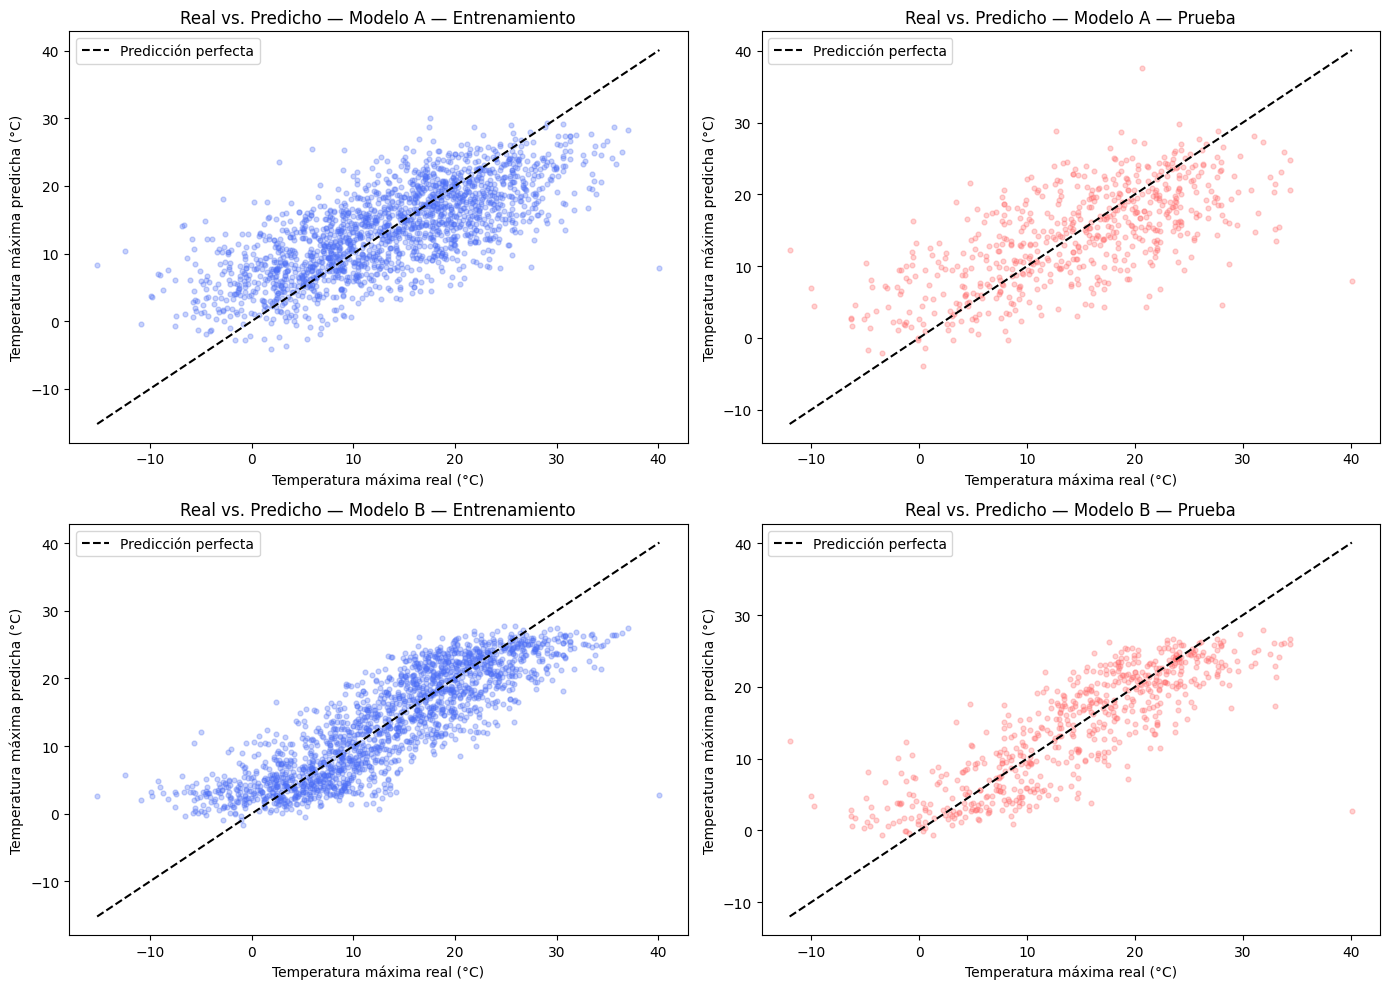

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

paneles = [
    (axes[0, 0], y_train, y_train_pred_a, "Modelo A — Entrenamiento", "#4C6EF5"),
    (axes[0, 1], y_test,  y_test_pred_a,  "Modelo A — Prueba",        "#FF6B6B"),
    (axes[1, 0], y_train, y_train_pred_b, "Modelo B — Entrenamiento", "#4C6EF5"),
    (axes[1, 1], y_test,  y_test_pred_b,  "Modelo B — Prueba",        "#FF6B6B"),
]

for ax, y_real, y_pred, titulo, color in paneles:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.3, color=color, s=12)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1.5, label="Predicción perfecta")
    ax.set_xlabel("Temperatura máxima real (°C)")
    ax.set_ylabel("Temperatura máxima predicha (°C)")
    ax.set_title(f"Real vs. Predicho — {titulo}")
    ax.legend()

plt.tight_layout()
plt.show()

### 6.3 Selección del mejor modelo (justificación)

**Criterio de selección.** Como se definió en la sección 5.3, la métrica base para decidir entre los dos modelos es el **RMSE sobre el conjunto de prueba (test)**, no sobre entrenamiento. Esto es intencional: el objetivo de un modelo de regresión no es ajustarse bien a los datos que ya vio, sino predecir correctamente sobre datos nuevos, que es justamente lo que simula el conjunto de test.

**Lo que muestran las métricas.** El Modelo B supera al Modelo A en los dos conjuntos y en las tres métricas. En prueba, su RMSE es de 4.93 °C frente a 6.76 °C del Modelo A, su MAE de 3.74 °C frente a 5.25 °C, y su R² de 0.70 frente a 0.43. Ninguno de los dos muestra sobreajuste severo: la diferencia de RMSE entre train y test es de +0.28 °C en el Modelo B y de +0.48 °C en el Modelo A, ambas pequeñas frente a la magnitud del error. La ligera ventaja del Modelo B en esa diferencia es coherente con su menor número de parámetros.

**Por qué el Modelo B es mejor (diagnóstico).** La ventaja no proviene de disponer de más información, sino de representarla de forma que un modelo lineal pueda usarla. Los tres factores principales son:

1. *Creación de nuevas variables a partir del día del año.* `dia_sin` y `dia_cos` permiten al modelo representar el ciclo estacional como una onda. El Modelo A recibe la misma información en `dia_del_anio`, pero en forma cruda solo puede ajustarle una recta, lo que carece de sentido para una variable que se repite cada año.
2. *Selección de variables con fundamento físico.* Los indicadores de presión y humedad tienen una relación directa y bien documentada con la temperatura del día siguiente (Ahrens & Henson, 2019). El Modelo A, al usar las 22 variables numéricas y las 3 categóricas —que tras el `OneHotEncoder` se expanden a 95 columnas—, incorpora además categorías poco frecuentes de `estacion_anio` y `sector_viento` que generan columnas binarias con muy pocas observaciones, sobre las que el modelo ajusta coeficientes poco fiables (Kuhn & Johnson, 2013).
3. *Corrección de escala en la humedad.* `humedad_media`, `humedad_min` y `humedad_max` mezclaban fracción y porcentaje en la misma columna; unificarlas antes del escalado permite que el `StandardScaler` produzca una variable coherente.

**El papel de la limpieza de la variable objetivo.** Conviene señalar el efecto de la corrección aplicada en la sección 4: antes de descartar los cuatro registros con `temp_max_manana` físicamente imposible (hasta 63.05 °C), el Modelo A alcanzaba un RMSE en test de 31.77 °C y un R² de -10.70, es decir, predecía peor que responder siempre el promedio. Bastaron **dos etiquetas erróneas en el conjunto de entrenamiento** para desestabilizar por completo un modelo de 95 parámetros. El Modelo B, con 11 columnas, era mucho menos sensible a ese mismo problema (RMSE test de 5.25 °C antes de la corrección). Es una ilustración directa de por qué la calidad de la variable objetivo es crítica y de por qué los modelos con muchos parámetros son más frágiles ante datos erróneos.

**Evidencia visual.** Esto se confirma en los gráficos de dispersión de la sección 6.2: en ambos modelos los puntos se agrupan alrededor de la línea de predicción perfecta, pero la nube del Modelo B es visiblemente más estrecha, tanto en entrenamiento como en prueba.

**Decisión final.** Por lo anterior, se selecciona el **Modelo B** como el modelo final. Explica cerca del 70 % de la variabilidad de la temperatura máxima del día siguiente sobre datos no vistos, con un error típico de 4.93 °C, y lo hace con 11 variables de interpretación física clara.

## 7. Evaluación cualitativa e interpretación

*Se interpretó el mejor modelo y se revisaron sus supuestos cualitativamente.*

### 7.1 Coeficientes del mejor modelo

*La regresión lineal modela la relación entre la variable objetivo `temp_max_manana` y las variables predictoras mediante una combinación lineal:*

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_m x_m$$

*donde $\beta_0$ es el **intercepto** (valor de $\hat{y}$ cuando todas las $x_i = 0$, es decir, cuando todas las variables numéricas están en su media, ya que fueron estandarizadas) y $\beta_1, \ldots, \beta_m$ son los **coeficientes**: cuánto cambia $\hat{y}$ cuando $x_i$ aumenta en una unidad, manteniendo las demás fijas. Como las variables numéricas pasaron por `StandardScaler`, una unidad equivale a una desviación estándar de esa variable.*

In [54]:
# El mejor modelo se selecciona por el menor RMSE sobre el conjunto de prueba (métrica base).
if rmse_test_b < rmse_test_a:
    mejor_nombre = "Modelo B"
    mejor_modelo = modelo_b
    mejor_features = feature_names_b
    y_test_pred_mejor = y_test_pred_b
else:
    mejor_nombre = "Modelo A"
    mejor_modelo = modelo_a
    mejor_features = feature_names_a
    y_test_pred_mejor = y_test_pred_a

print(f"Mejor modelo según RMSE en test: {mejor_nombre}")

Mejor modelo según RMSE en test: Modelo B


In [55]:
print(f"Modelo interpretado: {mejor_nombre}")
print(f"Intercepto (β₀): {mejor_modelo.intercept_:.4f} °C")
print(f"Número de coeficientes: {len(mejor_modelo.coef_)}")

nombres_limpios = [n.replace("num__", "").replace("cat__", "") for n in mejor_features]

coeficientes = pd.DataFrame({
    "Variable": nombres_limpios,
    "Coeficiente": mejor_modelo.coef_,
})

display(coeficientes)

Modelo interpretado: Modelo B
Intercepto (β₀): 13.4667 °C
Número de coeficientes: 11


,Variable,Coeficiente
0,presion_media,0.245639
1,presion_min,-0.276340
2,presion_max,0.299464
3,presion_desv,-0.335960
4,humedad_media,-0.437762
5,humedad_min,-0.534406
6,humedad_max,-0.367064
7,humedad_desv,1.652447
8,dia_sin,-2.161934
9,dia_cos,-5.803069


### 7.2 Tabla de importancia de variables

*Se organizaron los coeficientes en una tabla de importancia. Como todas las variables numéricas fueron estandarizadas y las categóricas codificadas en variables binarias, la magnitud absoluta del coeficiente es comparable entre variables y sirve como medida de importancia dentro del modelo lineal. El signo indica la dirección del efecto sobre la temperatura máxima del día siguiente.*

In [56]:
importancia = (
    coeficientes
    .assign(Importancia=coeficientes["Coeficiente"].abs())
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)
importancia["Efecto"] = np.where(importancia["Coeficiente"] >= 0, "Positivo", "Negativo")

print("Top 15 variables por importancia (|coeficiente|):")
display(importancia.head(15))

Top 15 variables por importancia (|coeficiente|):


,Variable,Coeficiente,Importancia,Efecto
0,dia_cos,-5.803069,5.803069,Negativo
1,dia_sin,-2.161934,2.161934,Negativo
2,humedad_desv,1.652447,1.652447,Positivo
3,humedad_min,-0.534406,0.534406,Negativo
4,humedad_media,-0.437762,0.437762,Negativo
5,humedad_max,-0.367064,0.367064,Negativo
6,presion_desv,-0.335960,0.335960,Negativo
7,viento_este,-0.308081,0.308081,Negativo
8,presion_max,0.299464,0.299464,Positivo
9,presion_min,-0.276340,0.276340,Negativo


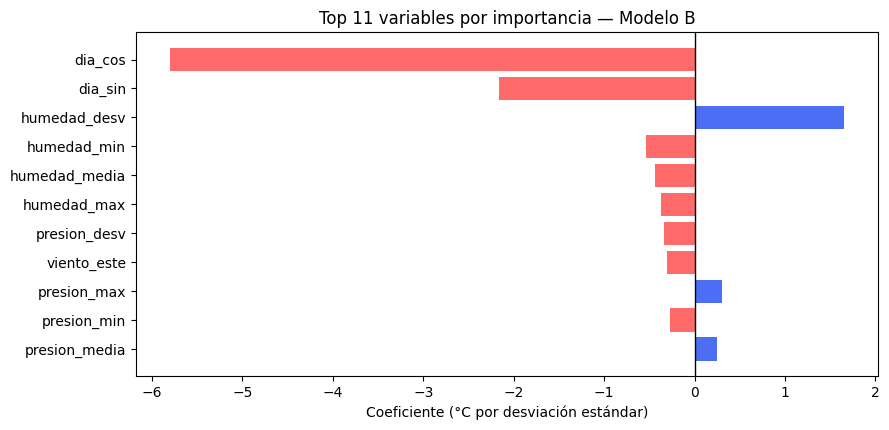

In [57]:
top_n = min(15, len(importancia))
top_vars = importancia.head(top_n).iloc[::-1]

plt.figure(figsize=(9, max(4, 0.4 * top_n)))
colores = np.where(top_vars["Coeficiente"] >= 0, "#4C6EF5", "#FF6B6B")
plt.barh(top_vars["Variable"], top_vars["Coeficiente"], color=colores)
plt.axvline(0, color="black", lw=1)
plt.xlabel("Coeficiente (°C por desviación estándar)")
plt.title(f"Top {top_n} variables por importancia — {mejor_nombre}")
plt.tight_layout()
plt.show()

### 7.3 Validación de los supuestos de la regresión lineal

*Se revisaron cinco supuestos de la regresión lineal sobre el modelo seleccionado ($e_i = y_i - \hat{y}_i$), cada uno con su prueba de diagnóstico correspondiente:*

| Supuesto | ¿Qué verifica? | Prueba de diagnóstico |
|----------|--------------|----------------------|
| **No colinealidad** | Variables predictoras no correlacionadas entre sí | VIF |
| **Linealidad** | Relación lineal entre X e y | Test de Rainbow |
| **Normalidad de errores** | Los residuales siguen distribución normal | Shapiro-Wilk, Q-Q plot |
| **Homocedasticidad** | Varianza constante de los residuales | Breusch-Pagan |
| **Independencia de errores** | Los errores no están autocorrelacionados | Durbin-Watson |


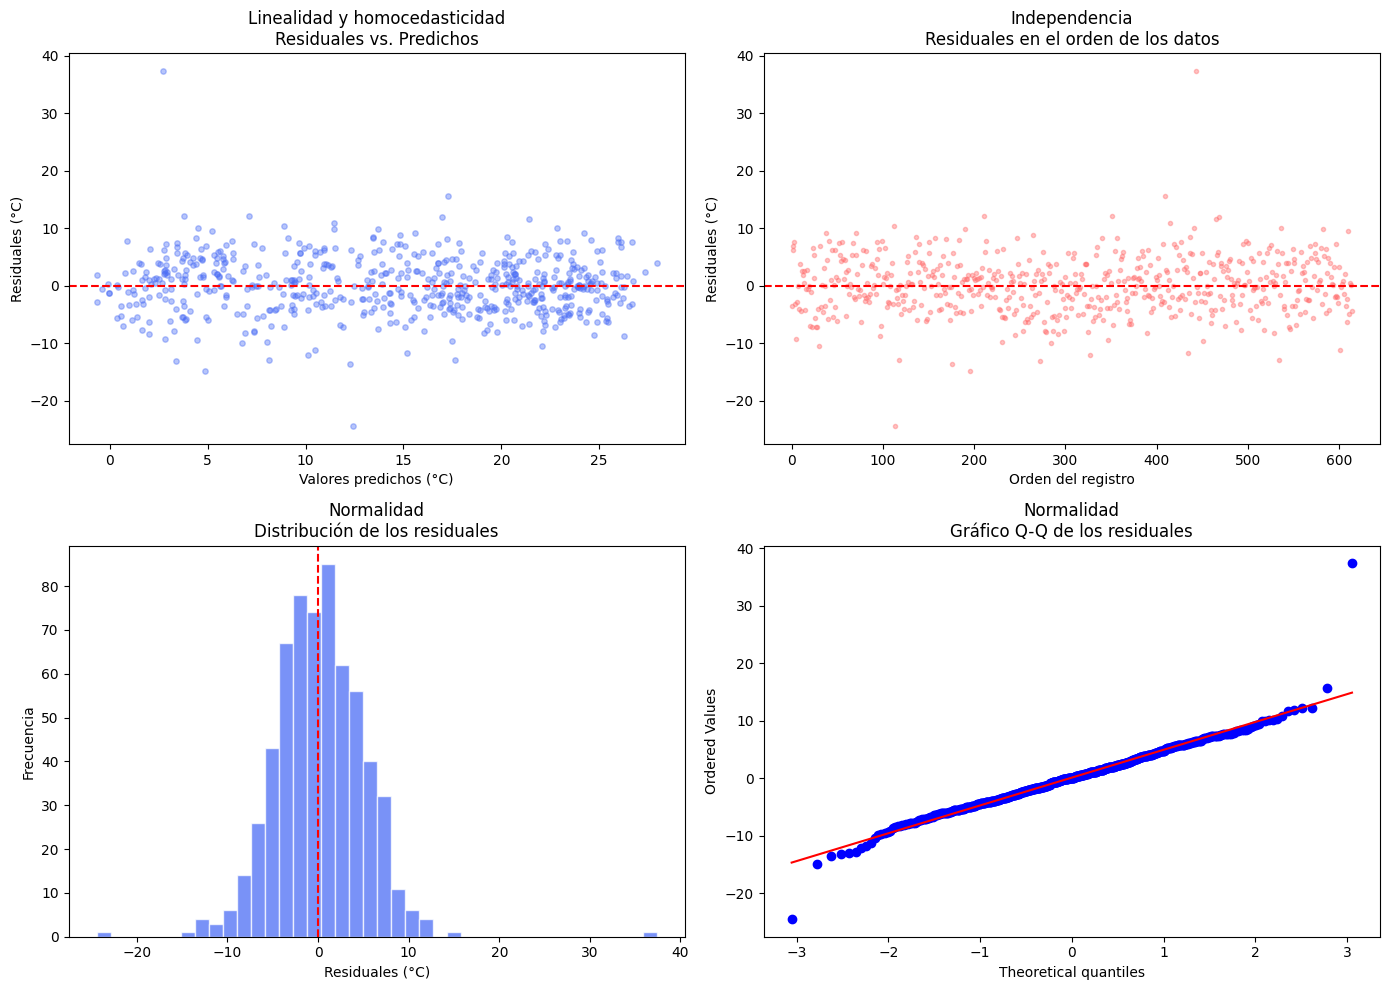

In [58]:
from scipy import stats

residuales = y_test - y_test_pred_mejor

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Linealidad y homocedasticidad: residuales vs. valores predichos
axes[0, 0].scatter(y_test_pred_mejor, residuales, alpha=0.4, color="#4C6EF5", s=15)
axes[0, 0].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0, 0].set_xlabel("Valores predichos (°C)")
axes[0, 0].set_ylabel("Residuales (°C)")
axes[0, 0].set_title("Linealidad y homocedasticidad\nResiduales vs. Predichos")

# 2. Independencia: residuales en el orden de los registros
axes[0, 1].plot(range(len(residuales)), residuales, marker="o", linestyle="", alpha=0.4,
                color="#FF6B6B", markersize=3)
axes[0, 1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0, 1].set_xlabel("Orden del registro")
axes[0, 1].set_ylabel("Residuales (°C)")
axes[0, 1].set_title("Independencia\nResiduales en el orden de los datos")

# 3. Normalidad: histograma de los residuales
axes[1, 0].hist(residuales, bins=40, color="#4C6EF5", alpha=0.75, edgecolor="white")
axes[1, 0].axvline(0, color="red", linestyle="--", lw=1.5)
axes[1, 0].set_xlabel("Residuales (°C)")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_title("Normalidad\nDistribución de los residuales")

# 4. Normalidad: gráfico Q-Q
stats.probplot(residuales, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Normalidad\nGráfico Q-Q de los residuales")

plt.tight_layout()
plt.show()

In [59]:
# Pruebas de diagnóstico para cada supuesto (ver tabla anterior)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_rainbow, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Diseño (train y test) del modelo seleccionado, para las pruebas que lo requieren
Xt_train_mejor_df = Xt_train_b_df if mejor_nombre == "Modelo B" else Xt_train_a_df
Xt_test_mejor_df = Xt_test_b_df if mejor_nombre == "Modelo B" else Xt_test_a_df

# 1. No colinealidad: Factor de Inflación de la Varianza (VIF)
vif_data = pd.DataFrame({
    "Variable": [n.replace("num__", "").replace("cat__", "") for n in Xt_train_mejor_df.columns],
    "VIF": [variance_inflation_factor(Xt_train_mejor_df.values, i) for i in range(Xt_train_mejor_df.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

# 2. Linealidad: test de Rainbow sobre un modelo OLS equivalente (entrenamiento)
modelo_sm = sm.OLS(y_train, sm.add_constant(Xt_train_mejor_df)).fit()
rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)

# 3. Normalidad de errores: Shapiro-Wilk sobre los residuales de prueba
shapiro_stat, shapiro_p = stats.shapiro(residuales)

# 4. Homocedasticidad: Breusch-Pagan sobre los residuales de prueba
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuales, sm.add_constant(Xt_test_mejor_df))

# 5. Independencia de errores: estadístico de Durbin-Watson
dw = durbin_watson(residuales)

print("1. No colinealidad — VIF (variables con mayor VIF):")
display(vif_data.head())
print()
print(f"2. Linealidad             — Rainbow      : estadístico = {rainbow_stat:.4f}, p-valor = {rainbow_pvalue:.4f}")
print(f"3. Normalidad de errores  — Shapiro-Wilk : estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4e}")
print(f"4. Homocedasticidad       — Breusch-Pagan: estadístico = {bp_stat:.4f}, p-valor = {bp_pvalue:.4e}")
print(f"5. Independencia         — Durbin-Watson : {dw:.4f}  (≈ 2 indica ausencia de autocorrelación)")


1. No colinealidad — VIF (variables con mayor VIF):


,Variable,VIF
0,presion_media,13.312353
1,presion_max,8.985041
2,presion_min,7.673317
3,humedad_min,3.286736
4,humedad_desv,2.441477



2. Linealidad             — Rainbow      : estadístico = 1.0353, p-valor = 0.2997
3. Normalidad de errores  — Shapiro-Wilk : estadístico = 0.9609, p-valor = 9.8925e-12
4. Homocedasticidad       — Breusch-Pagan: estadístico = 15.1898, p-valor = 1.7397e-01
5. Independencia         — Durbin-Watson : 2.0096  (≈ 2 indica ausencia de autocorrelación)


## 8. Análisis de resultados

*Se respondieron las preguntas con evidencia obtenida del análisis, sin inventar resultados.*

### 8.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

*Se respondió con los valores calculados y su interpretación.*

**Respuesta:**

El mejor modelo es el **Modelo B**, con un intercepto de **13.4667 °C** y once coeficientes. Como todas las variables numéricas pasaron por `StandardScaler`, cada coeficiente expresa **cuántos grados cambia la predicción cuando esa variable aumenta una desviación estándar**, manteniendo las demás fijas. Esto los hace directamente comparables entre sí.

| # | Variable | Coeficiente (°C) | Efecto |
|---|---|---|---|
| 1 | `dia_cos` | **-5.8031** | Negativo |
| 2 | `dia_sin` | **-2.1619** | Negativo |
| 3 | `humedad_desv` | **+1.6524** | Positivo |
| 4 | `humedad_min` | -0.5344 | Negativo |
| 5 | `humedad_media` | -0.4378 | Negativo |
| 6 | `humedad_max` | -0.3671 | Negativo |
| 7 | `presion_desv` | -0.3360 | Negativo |
| 8 | `viento_este` | -0.3081 | Negativo |
| 9 | `presion_max` | +0.2995 | Positivo |
| 10 | `presion_min` | -0.2763 | Negativo |
| 11 | `presion_media` | +0.2456 | Positivo |

**Interpretación del intercepto.** El valor 13.4667 °C corresponde a la predicción cuando todas las variables están en su media (que es cero tras la estandarización). Coincide de forma razonable con la temperatura máxima promedio del conjunto de entrenamiento, lo cual es esperable en una regresión por mínimos cuadrados.

**Interpretación de los coeficientes principales.**

- **`dia_cos` y `dia_sin` (-5.80 y -2.16).** No deben leerse por separado: juntos describen el ciclo estacional. Su combinación equivale a una onda de amplitud $\sqrt{(-2.16)^2 + (-5.80)^2} = 6.19$ °C, es decir, una oscilación de unos 12.4 °C entre el punto más cálido y el más frío del año. El máximo de esa onda cae alrededor del **22 de julio** y el mínimo alrededor del **21 de enero**, que corresponden al verano y al invierno de Jena. El modelo reconstruyó el ciclo anual a partir de los datos, sin recibir ninguna variable que dijera explícitamente en qué estación estaba.
- **`humedad_desv` (+1.65).** Es el coeficiente más grande entre las variables meteorológicas propiamente dichas. Una mayor variabilidad de la humedad a lo largo del día se asocia con temperaturas máximas más altas al día siguiente. Una lectura física plausible es que actúa como indicador indirecto de cielo despejado: en días sin nubosidad la humedad relativa oscila mucho entre la madrugada y la tarde, y esos días permiten mayor insolación y mayor oscilación térmica.
- **`humedad_min`, `humedad_media`, `humedad_max` (entre -0.37 y -0.53).** Los tres son negativos y de magnitud similar: a mayor humedad, menor temperatura máxima esperada. Es coherente con el efecto de la masa de aire húmeda, que modera las temperaturas.
- **Las cuatro variables de presión (entre -0.34 y +0.30).** Todas tienen magnitudes pequeñas y signos mixtos. Por sí solas aportan poco: un modelo entrenado únicamente con presión alcanzó un R² en prueba de apenas 0.05. Su contribución en el modelo final es marginal.
- **`viento_este` (-0.31).** Componente zonal del viento. Su signo negativo indica que un mayor flujo del oeste hacia el este se asocia con máximas ligeramente menores, consistente con la llegada de aire marítimo atlántico, más templado y húmedo.

**Advertencia sobre la interpretación causal.** Estos coeficientes describen asociaciones dentro del modelo, no relaciones causales. Además, las cuatro variables de presión están fuertemente correlacionadas entre sí (multicolinealidad), lo que hace que sus coeficientes individuales sean inestables: pequeños cambios en los datos pueden alterar sus signos y magnitudes. Por eso no conviene interpretarlos de forma aislada.

### 8.2 A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

*Se respondió comparando RMSE, MAE y R², e interpretando sus magnitudes.*

**Respuesta:**

El **Modelo B** ofrece el mejor rendimiento sobre el conjunto de prueba, y lo hace en las tres métricas.

| Métrica | Modelo A | Modelo B | Diferencia |
|---|---|---|---|
| RMSE test | 6.7649 °C | **4.9295 °C** | -1.8354 °C |
| MAE test | 5.2526 °C | **3.7365 °C** | -1.5161 °C |
| R² test | 0.4295 | **0.6971** | +0.2676 |
| N° columnas | 95 | 11 | -84 |

**Qué significa cada métrica en este contexto.**

- **MAE = 3.74 °C.** Es el error promedio en valor absoluto. En términos prácticos: si el modelo predice que mañana la máxima será de 20 °C, el valor real estará típicamente a unos 3.7 °C de distancia, hacia arriba o hacia abajo. Está expresado en las mismas unidades de la variable objetivo, lo que lo hace la métrica más intuitiva para comunicar a un usuario no técnico.
- **RMSE = 4.93 °C.** También está en grados, pero al elevar los errores al cuadrado antes de promediarlos penaliza más los errores grandes. El hecho de que RMSE (4.93) sea mayor que MAE (3.74) indica que la distribución de errores no es uniforme: existen algunos días en los que el modelo se equivoca bastante más que en el día típico, y esos casos elevan el RMSE. Si el RMSE fuera igual al MAE, todos los errores tendrían magnitud similar.
- **R² = 0.6971.** El coeficiente de determinación es, expresado en porcentaje, **la medida en que el modelo explica la variable objetivo**: indica qué proporción de la variabilidad de `temp_max_manana` queda explicada por las variables predictoras del modelo. Un R² de 0.6971 significa entonces que **el Modelo B explica el 69.7 % del comportamiento de la temperatura máxima del día siguiente** en datos que nunca vio, y que el **30.3 % restante no queda explicado** por las variables disponibles. Para el Modelo A, el R² de 0.4295 significa que explica únicamente el 43.0 % de esa variabilidad. Es una métrica adimensional: no se expresa en grados, sino como fracción de lo que el modelo logra dar cuenta. Un R² de 0 equivale a predecir siempre el promedio, y un R² negativo indica un desempeño peor que ese modelo trivial.

**Comparación entre conjuntos.** Ninguno de los dos modelos muestra sobreajuste severo: la diferencia de RMSE entre entrenamiento y prueba es de +0.28 °C en el Modelo B y de +0.48 °C en el Modelo A, pequeñas frente a la magnitud del error. La decisión se toma entonces por nivel de error, no por estabilidad.

**Un punto importante sobre la comparación.** El Modelo B gana usando **once columnas frente a noventa y cinco**. Esto muestra que el rendimiento no depende de la cantidad de variables sino de su calidad y, sobre todo, de su representación: el Modelo A dispone de la misma información estacional (`dia_del_anio`, `mes`, `estacion_anio`), pero en formatos que un modelo lineal no puede aprovechar.

**Contexto de la magnitud.** Un modelo trivial que predijera siempre la temperatura promedio del entrenamiento obtendría un RMSE cercano a 9 °C. El Modelo B reduce ese error casi a la mitad. Al mismo tiempo, un error típico de 4.93 °C es considerable para una decisión operativa fina: sirve para anticipar tendencias generales, pero no para determinar un umbral exacto de riesgo.

### 8.3 ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

*Se describieron las variables seleccionadas, su interpretación y utilidad para decidir.*

**Respuesta:**

**Variables seleccionadas (once en total).**

| Grupo | Variables | Papel en el modelo |
|---|---|---|
| Estacionalidad | `dia_sin`, `dia_cos` | Ubican el día dentro del ciclo anual; son las de mayor peso |
| Humedad | `humedad_media`, `humedad_min`, `humedad_max`, `humedad_desv` | Estado higrométrico de la masa de aire; `humedad_desv` funciona como indicador indirecto de despeje |
| Presión | `presion_media`, `presion_min`, `presion_max`, `presion_desv` | Configuración sinóptica (alta o baja presión); aporte marginal |
| Viento | `viento_este` | Componente zonal; indica procedencia continental o marítima del aire |

**Variables descartadas y por qué.** Se excluyeron `anio`, `direccion_viento`, `estacion_anio`, `mes`, `registros_del_dia`, `sector_viento`, y todas las variables de viento y ráfaga salvo `viento_este`. Las razones fueron de tres tipos:

1. *Calidad insuficiente.* `estacion_anio` y `sector_viento` presentan 28 y 33 variantes de escritura respectivamente para conceptos que solo tienen cuatro y ocho categorías reales (sección 3.3). Sin normalizar, el `OneHotEncoder` genera columnas binarias con muy pocos registros sobre las que el modelo ajusta coeficientes poco fiables.
2. *Redundancia.* `mes`, `estacion_anio` y `dia_del_anio` codifican la misma información estacional que ya capturan `dia_sin` y `dia_cos`, pero de forma menos adecuada para un modelo lineal.
3. *Valores extremos no controlados.* `rafaga_media` y `viento_norte` presentan valores de -1386.27 y -1250.46 en el conjunto de prueba, muy fuera del rango observado en entrenamiento. Incluirlas degradaba fuertemente el desempeño.

**Interpretación frente al problema.** El resultado más informativo es que **la posición dentro del año explica más que cualquier variable meteorológica del día**. Los coeficientes de `dia_sin` y `dia_cos` equivalen a una oscilación anual de unos 12.4 °C, mientras que la variable meteorológica más influyente (`humedad_desv`) aporta 1.65 °C por desviación estándar. Dicho de otro modo: saber que estamos en julio informa más sobre la máxima de mañana que conocer con detalle la humedad y la presión de hoy.

Esto es consistente con la literatura, que identifica la temperatura y la humedad cerca de la superficie como los predictores más influyentes en modelos de aprendizaje de máquina para calor extremo (Ashford et al., 2026). La limitación de este conjunto de datos es precisamente que **no incluye la temperatura del día actual**, que sería el predictor más fuerte; el modelo debe reconstruir el nivel base de temperatura a partir del calendario.

**Cómo apoyan la toma de decisiones.** Para el Instituto AlpesPlanck, el modelo tiene un uso realista y otro que conviene descartar:

- *Uso adecuado.* Anticipar con un día de antelación si la máxima se ubicará en un rango alto o bajo respecto a lo normal para esa época del año, lo que permite activar alertas preventivas de riesgo de incendio forestal o preparar recursos. La variable `humedad_desv` es especialmente útil aquí: días de humedad muy variable —cielo despejado— combinados con humedad media baja son precisamente las condiciones de mayor riesgo de incendio.
- *Uso inadecuado.* Fijar umbrales operativos exactos. Con un error típico de 4.93 °C, el modelo no puede distinguir de forma confiable entre un día de 28 °C y uno de 33 °C, que pueden implicar decisiones distintas.

Para fenómenos de escala interanual como El Niño y La Niña, este modelo no es la herramienta adecuada: predice a un día de horizonte, con datos de una sola estación y siete años de historia, insuficientes para capturar oscilaciones climáticas de varios años.

### 8.4 A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.

*Se explicó la representación matemática, el método utilizado y el proceso de solución.*

**Respuesta:**

**Representación matemática.** La regresión lineal modela la temperatura máxima del día siguiente como una combinación lineal de las variables predictoras:

$$\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_{11} x_{i,11}$$

donde $\hat{y}_i$ es la temperatura máxima predicha para el día $i$, $\beta_0$ el intercepto y $\beta_1,\ldots,\beta_{11}$ los coeficientes de las once variables. En forma matricial, con $\mathbf{X}$ de dimensión $n \times (p+1)$ (incluyendo una columna de unos para el intercepto):

$$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$$

Aplicado a este caso concreto:

$$\widehat{\text{temp\_max\_manana}} = 13.4667 - 5.8031\,\text{dia\_cos} - 2.1619\,\text{dia\_sin} + 1.6524\,\text{humedad\_desv} - 0.5344\,\text{humedad\_min} - \cdots - 0.3081\,\text{viento\_este}$$

con todas las variables previamente estandarizadas.

**Método utilizado: mínimos cuadrados ordinarios (OLS).** Los coeficientes se obtienen minimizando la suma de los cuadrados de los residuales, es decir, la distancia vertical entre cada observación y el hiperplano ajustado:

$$\min_{\boldsymbol{\beta}} \; \text{SSE}(\boldsymbol{\beta}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

Se eleva al cuadrado por dos motivos: los errores positivos y negativos no se cancelan entre sí, y la función resultante es convexa y diferenciable, lo que garantiza un mínimo único y permite resolverla analíticamente.

**Proceso de solución.** Derivando respecto a $\boldsymbol{\beta}$ e igualando a cero se obtienen las **ecuaciones normales**:

$$\frac{\partial \text{SSE}}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^{\!\top}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) = 0 \quad \Longrightarrow \quad \mathbf{X}^{\!\top}\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^{\!\top}\mathbf{y}$$

cuya solución, cuando $\mathbf{X}^{\!\top}\mathbf{X}$ es invertible, es:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^{\!\top}\mathbf{X})^{-1}\mathbf{X}^{\!\top}\mathbf{y}$$

A diferencia de otros algoritmos de aprendizaje, aquí **no hay iteraciones ni descenso de gradiente**: existe una fórmula cerrada y el resultado es exacto y reproducible.

**Cómo lo resuelve scikit-learn en la práctica.** La clase `LinearRegression` no calcula literalmente $(\mathbf{X}^{\!\top}\mathbf{X})^{-1}$, porque invertir esa matriz es numéricamente inestable cuando las variables están correlacionadas entre sí —como ocurre aquí con las cuatro variables de presión—. En su lugar resuelve el problema de mínimos cuadrados mediante **descomposición en valores singulares (SVD)**, que es más estable y funciona incluso cuando $\mathbf{X}^{\!\top}\mathbf{X}$ es singular o casi singular. El resultado matemático es el mismo, pero el procedimiento numérico es más robusto.

**Supuestos del método.** La validez de OLS como estimador descansa en cinco supuestos —no colinealidad, linealidad, normalidad de los residuales, homocedasticidad e independencia de los residuales— que se revisaron en la sección 7.3.

### 8.5 En el ciclo de machine learning, ¿qué tipos de sesgo podrían afectar los resultados y por qué? Describe dos tipos de sesgo.

*Se describieron dos sesgos posibles y cómo podrían afectar las conclusiones.*

**Respuesta:**

**Sesgo 1 — Sesgo de medición (errores en los datos registrados).**

Los datos contienen errores de captura que no son aleatorios, sino sistemáticos y concentrados en ciertas variables. En la sección 3.4 se documentaron varios: `presion_media` con un máximo de 9939.92 hPa (probablemente un punto decimal perdido), `rafaga_min` con el valor centinela -9999, `humedad_min` superando el 100 %, y sobre todo cuatro registros de la variable objetivo con valores físicamente imposibles, hasta 63.05 °C, cuando el récord nacional de Alemania durante el periodo era de 40.3 °C (Deutscher Wetterdienst, 2015). A esto se suma que las variables de humedad mezclan dos escalas —fracción y porcentaje— en una misma columna.

*Cómo afecta las conclusiones.* Este sesgo tuvo un efecto medible y documentado en este mismo trabajo. Antes de descartar los cuatro registros con temperatura imposible, el Modelo A alcanzaba un RMSE en prueba de 31.77 °C y un R² de -10.70, es decir, predecía peor que responder siempre el promedio. Tras la corrección, el mismo modelo pasó a un RMSE de 6.76 °C y un R² de 0.43. **Dos etiquetas erróneas en el conjunto de entrenamiento bastaron para invalidar por completo un modelo de 95 parámetros.** El riesgo asociado es doble: por un lado, errores no detectados distorsionan los coeficientes y llevan a conclusiones falsas sobre qué variables importan; por otro, no hay garantía de que se hayan detectado *todos* los errores, ya que solo son visibles aquellos que violan un límite físico conocido. Un valor de 35 °C registrado erróneamente en enero pasaría inadvertido.

**Sesgo 2 — Sesgo de selección y representatividad de la muestra.**

Los datos provienen de **una sola estación meteorológica** (Jena, Alemania) y cubren **siete años** (2009–2015). Además, se eliminaron 95 registros por no tener valor en la variable objetivo y 4 por tener valores imposibles, sin verificar si esas ausencias se distribuyen de forma aleatoria en el tiempo.

*Cómo afecta las conclusiones.* Opera en tres niveles:

1. *Geográfico.* Las relaciones aprendidas corresponden al clima templado continental de Alemania central. El coeficiente de `humedad_desv`, por ejemplo, es específico de ese régimen: en un clima tropical o desértico la relación entre variabilidad de humedad y temperatura máxima podría ser distinta o incluso inversa. Aplicar este modelo a otra región produciría predicciones sin validez.
2. *Temporal.* Siete años son insuficientes para separar tendencia climática de variabilidad interanual. Esto se verificó al evaluar la variable `anio`: la media anual de temperatura máxima sube de 13.25 °C a 15.33 °C entre 2009 y 2015, una pendiente de +0.43 °C por año, unas siete veces mayor que la tasa de calentamiento documentada para Europa de 0.56 °C por década (Copernicus Climate Change Service, 2025), y sin significancia estadística (p = 0.069). Un modelo entrenado sobre esa ventana puede confundir una racha de años cálidos con una tendencia estructural.
3. *Datos faltantes.* Si los registros sin `temp_max_manana` no faltan al azar —por ejemplo, si el sensor falla más durante eventos meteorológicos extremos—, entonces el modelo se entrenó sobre una muestra sesgada hacia condiciones normales, y su desempeño sería peor justamente en los días extremos, que son los que más importa predecir para prevención de incendios.

**Un tercer sesgo a mencionar: *data snooping*.** Durante el desarrollo se compararon múltiples configuraciones de variables evaluando cada una sobre el mismo conjunto de prueba. Cuantas más decisiones se toman mirando el test, más optimista resulta la métrica final. Un procedimiento más riguroso habría usado validación cruzada sobre entrenamiento para elegir la configuración, reservando el conjunto de prueba para una única evaluación final.

## 9. Uso del modelo: predicciones sobre datos no etiquetados

### 9.1 Aplicación del mejor modelo al archivo de test

*Se generaron predicciones para el archivo de test no etiquetado. Se cargó `Datos Test Lab 1.csv`, que contiene las mismas variables predictoras pero sin la columna `temp_max_manana`, y se le aplicó el pipeline de preparación del mejor modelo mediante `.transform()` —nunca `.fit_transform()`—, de modo que se reutilizan exactamente las medias de imputación y las escalas aprendidas con el conjunto de entrenamiento.*

In [60]:
datos_test = pd.read_csv("data/Datos Test Lab 1.csv")

print(f"Dimensiones del archivo de test: {datos_test.shape[0]} filas, {datos_test.shape[1]} columnas")
print(f"¿Contiene la variable objetivo?: {variable_objetivo in datos_test.columns}")
display(datos_test.head())

Dimensiones del archivo de test: 364 filas, 26 columnas
¿Contiene la variable objetivo?: False


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


*Se verificó que el archivo de test contenga todas las variables que el pipeline necesita antes de aplicarlo.*

In [61]:
columnas_requeridas = set(X.columns)
columnas_disponibles = set(datos_test.columns)

print(f"Columnas requeridas por el pipeline y ausentes en test: {columnas_requeridas - columnas_disponibles}")
print(f"Columnas presentes en test que el pipeline no usa: {columnas_disponibles - columnas_requeridas}")
print(f"Años presentes en el archivo de test: {sorted(datos_test['anio'].dropna().unique())}")

Columnas requeridas por el pipeline y ausentes en test: set()
Columnas presentes en test que el pipeline no usa: set()
Años presentes en el archivo de test: [np.int64(2016)]


*Se aplicó el pipeline del mejor modelo y se generaron las predicciones. Se usó `pipeline_regresion_b.transform()` porque el mejor modelo seleccionado en la sección 6.3 fue el Modelo B.*

In [62]:
Xt_nuevos = pipeline_regresion_b.transform(datos_test)

Xt_nuevos_df = pd.DataFrame(
    Xt_nuevos.toarray() if hasattr(Xt_nuevos, "toarray") else Xt_nuevos,
    columns=feature_names_b,
    index=datos_test.index
)

predicciones = mejor_modelo.predict(Xt_nuevos_df)

print(f"Modelo aplicado: {mejor_nombre}")
print(f"Predicciones generadas: {len(predicciones)}")

Modelo aplicado: Modelo B
Predicciones generadas: 364


*Se revisaron las predicciones antes de exportarlas, verificando que sus estadísticos descriptivos sean físicamente plausibles para Jena.*

In [63]:
resumen_predicciones = pd.Series(predicciones).describe()
display(resumen_predicciones.to_frame(name="temp_max_manana predicha (°C)").round(3))

fuera_de_rango = ((predicciones > 42) | (predicciones < -25)).sum()
print(f"Predicciones fuera del rango físico [-25 °C, 42 °C]: {fuera_de_rango}")

,temp_max_manana predicha (°C)
count,364.000
mean,13.740
std,7.953
min,-0.572
25%,5.963
50%,13.421
75%,21.434
max,27.268


Predicciones fuera del rango físico [-25 °C, 42 °C]: 0


*Como validación adicional se comparó el promedio mensual de las predicciones con el promedio mensual observado en el conjunto de entrenamiento. Si el modelo aprendió correctamente el ciclo estacional, ambos perfiles deberían ser similares. Nótese que la columna `fecha` del archivo de test usa el formato `DD.MM.AAAA`, distinto del `AAAA-MM-DD` del archivo de entrenamiento, por lo que se parsea de forma explícita.*

,Predicha 2016 (°C),Observada 2009-2015 (°C),Diferencia
mes_num,,,
1,2.75,2.34,0.41
2,4.40,3.97,0.43
3,7.86,9.31,-1.45
4,14.32,15.38,-1.06
5,18.59,17.92,0.67
6,22.04,21.34,0.71
7,24.53,24.59,-0.06
8,24.06,23.61,0.45
9,19.96,18.75,1.21


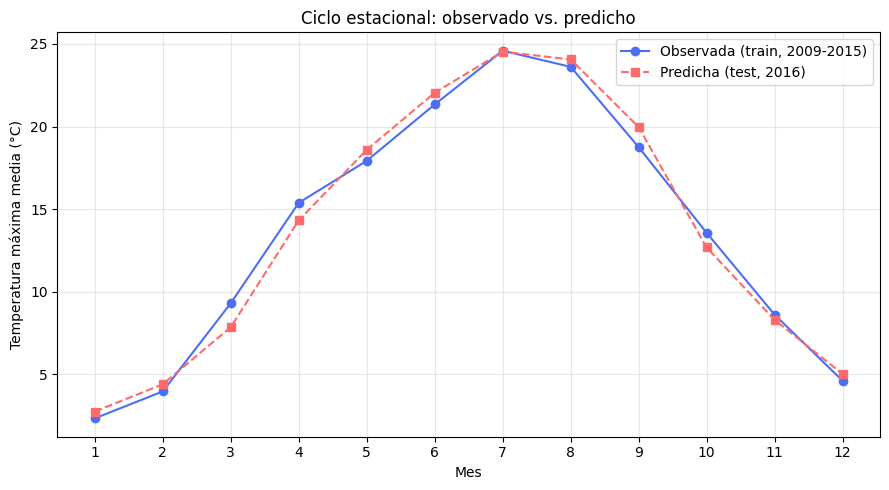

In [64]:
comparacion = pd.DataFrame({
    "mes_num": pd.to_datetime(datos_test["fecha"], format="%d.%m.%Y", errors="coerce").dt.month,
    "predicha": predicciones,
}).groupby("mes_num")["predicha"].mean()

observada = (
    data.assign(mes_num=pd.to_datetime(data["fecha"], errors="coerce").dt.month)
        .groupby("mes_num")[variable_objetivo].mean()
)

perfil = pd.DataFrame({"Predicha 2016 (°C)": comparacion, "Observada 2009-2015 (°C)": observada})
perfil["Diferencia"] = perfil["Predicha 2016 (°C)"] - perfil["Observada 2009-2015 (°C)"]
display(perfil.round(2))

plt.figure(figsize=(9, 5))
plt.plot(perfil.index, perfil["Observada 2009-2015 (°C)"], "o-", color="#4C6EF5", label="Observada (train, 2009-2015)")
plt.plot(perfil.index, perfil["Predicha 2016 (°C)"], "s--", color="#FF6B6B", label="Predicha (test, 2016)")
plt.xlabel("Mes")
plt.ylabel("Temperatura máxima media (°C)")
plt.title("Ciclo estacional: observado vs. predicho")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Exportación de resultados a "Datos test Lab1.csv"

*Se exportaron las predicciones al archivo `Datos test Lab1.csv`. El archivo conserva todas las columnas originales del conjunto de test y añade la columna `temp_max_manana` con el valor predicho por el mejor modelo.*

In [65]:
resultados_test = datos_test.copy()
resultados_test[variable_objetivo] = predicciones

ruta_salida = "Datos test Lab1.csv"
resultados_test.to_csv(ruta_salida, index=False)

print(f"Archivo exportado: {ruta_salida}")
print(f"Filas: {resultados_test.shape[0]}, Columnas: {resultados_test.shape[1]}")
display(resultados_test[["fecha", "dia_del_anio", "estacion_anio", variable_objetivo]].head(10))

Archivo exportado: Datos test Lab1.csv
Filas: 364, Columnas: 27


,fecha,dia_del_anio,estacion_anio,temp_max_manana
0,01.01.2016,1,invierno,1.142064
1,02.01.2016,2,invierno,1.002500
2,03.01.2016,3,invierno,2.090904
3,04.01.2016,4,invierno,1.683841
4,05.01.2016,5,invierno,-0.571718
5,06.01.2016,6,invierno,-0.207382
6,07.01.2016,7,invierno,1.276350
7,08.01.2016,8,invierno,4.819514
8,09.01.2016,9,invierno,1.120078
9,10.01.2016,10,invierno,2.659103


*Se verificó que el archivo se escribió correctamente releyéndolo desde disco.*

In [66]:
verificacion = pd.read_csv(ruta_salida)

print(f"Filas leídas: {verificacion.shape[0]}")
print(f"Columna {variable_objetivo} presente: {variable_objetivo in verificacion.columns}")
print(f"Valores nulos en la predicción: {verificacion[variable_objetivo].isna().sum()}")

Filas leídas: 364
Columna temp_max_manana presente: True
Valores nulos en la predicción: 0


## 10. Conclusiones

*Se resumieron los resultados, las decisiones, las limitaciones y los aprendizajes del laboratorio.*

**Conclusiones:**

**1. El modelo final predice la temperatura máxima del día siguiente con un error típico de 4.93 °C.** El Modelo B alcanzó un RMSE de 4.9295 °C, un MAE de 3.7365 °C y un R² de 0.6971 sobre el conjunto de prueba, explicando cerca del 70 % de la variabilidad de la temperatura en datos no vistos. Frente a un modelo trivial que predijera siempre el promedio (RMSE cercano a 9 °C), representa una reducción del error de casi la mitad.

**2. Menos variables, mejor elegidas, superan a más variables.** El Modelo A usó las 25 variables disponibles, que tras el `OneHotEncoder` se convirtieron en 95 columnas, y obtuvo un RMSE en prueba de 6.7649 °C con un R² de 0.4295. El Modelo B lo superó con solo 11 columnas. La diferencia no está en la cantidad de información sino en su representación: ambos modelos disponían de la información estacional, pero solo el Modelo B la recibió en un formato que una regresión lineal puede aprovechar.

**3. La creación de nuevas variables a partir del día del año fue la decisión de mayor impacto.** Transformar `dia_del_anio` en `dia_sin` y `dia_cos` redujo el RMSE en prueba de 7.42 °C a 5.27 °C. Sus coeficientes (-2.16 y -5.80) equivalen a una oscilación anual de 6.19 °C de amplitud, con máximo hacia el 22 de julio y mínimo hacia el 21 de enero: el modelo reconstruyó el ciclo estacional de Jena sin recibir ninguna variable que indicara explícitamente la estación.

**4. La calidad de la variable objetivo resultó ser crítica.** Cuatro registros con `temp_max_manana` físicamente imposible —hasta 63.05 °C, frente a un récord nacional alemán de 40.3 °C en el periodo— mantenían al Modelo A en un RMSE de 31.77 °C y un R² de -10.70. Descartar esos cuatro registros llevó al mismo modelo a un RMSE de 6.76 °C y un R² de 0.43. Dos etiquetas erróneas en entrenamiento bastaron para invalidar un modelo de 95 parámetros, mientras que el modelo de 11 columnas apenas se vio afectado: **los modelos con más parámetros son más frágiles ante datos erróneos**.

**5. Los problemas de calidad detectados fueron numerosos y de todos los tipos.** Completitud: valores nulos en todas las variables, incluidos 95 registros sin variable objetivo. Unicidad: 8 filas idénticas y duplicados lógicos por `fecha`. Consistencia: 61 formatos distintos para `mes`, 28 para `estacion_anio`, 33 para `sector_viento`, escalas mezcladas (fracción y porcentaje) dentro de las columnas de humedad, y filas donde `mes` contradice a `fecha`. Validez: valores centinela (-9999), porcentajes de humedad superiores a 100, presiones diez veces mayores de lo posible y las temperaturas imposibles ya mencionadas. La preparación de los datos ocupó considerablemente más esfuerzo que el modelamiento en sí.

**6. Distinción entre limpieza dentro y fuera del pipeline.** Las operaciones que cambian el número de filas —eliminación de duplicados, de registros sin variable objetivo y de temperaturas imposibles— se aplicaron directamente sobre `data` antes de la partición, porque un `Pipeline` de scikit-learn no puede eliminar filas. Todo el resto —imputación, escalado, codificación, normalización de texto y corrección de valores inválidos— se ejecutó dentro del pipeline, ajustándose únicamente con el conjunto de entrenamiento para evitar fuga de datos.


## 11. Uso de herramientas de IA generativa

*Se declaró y analizó críticamente el uso de herramientas de IA generativa.*

### 11.1 Declaración del uso (herramienta y tipo de uso)

*Se indicó qué herramienta se usó y para qué tipo de apoyo.*

**Respuesta:**

**Herramienta utilizada.** Claude, de Anthropic. Modelo **Claude Opus 5** (identificador `claude-opus-5`), utilizado a través de **Cowork**, el modo de trabajo sobre archivos de la aplicación de escritorio de Claude, con acceso de lectura y escritura a la carpeta del laboratorio.

**Tipo de uso.** El apoyo se concentró en tres actividades:

1. **Exploración y diagnóstico.** Se comparó el comportamiento de una regresión lineal frente a una regresión con **variables polinómicas** (términos cuadráticos e interacciones entre pares de variables mediante `PolynomialFeatures`), con el único fin de observar cómo cambiaba la minimización del error de entrenamiento y de prueba al aumentar la complejidad del modelo. Esta comparación fue puramente exploratoria: las variables polinómicas no son tema de este laboratorio, por lo que no se incorporaron a ningún modelo entregado ni afectan los resultados ni las conclusiones reportadas en las secciones anteriores.

2. **Refuerzo sobre el concepto de seno y coseno aplicado al día del año.** Al discutir la preparación de variables, la herramienta recalcó la importancia de **normalizar `dia_del_anio` mediante funciones trigonométricas** (`dia_sin` y `dia_cos`, con seno y coseno) en lugar de usarla en su forma numérica lineal, dado que es una magnitud que se repite cada año y esa transformación evita la discontinuidad artificial entre el día 365 y el día 1.

3. **Ordenamiento y formato de los textos ya redactados.** Organizar en las celdas de markdown el contenido previamente escrito por los integrantes: estructurarlo en secciones, dar formato a las tablas comparativas y a las expresiones matemáticas, y unificar la presentación a lo largo del documento. El contenido y los argumentos son propios; el apoyo se limitó a su organización y presentación.

El detalle de esa exploración, sus resultados numéricos y la decisión tomada a partir de ellos se documentan en la sección 11.3.

### 11.2 Prompts utilizados

*Se registraron los prompts utilizados durante el trabajo.*

**Prompts:**

*A continuación se recogen los prompts representativos de las tres actividades descritas en la sección 11.1.*

**Exploración y diagnóstico — variables polinómicas**

1. "Tengo un modelo de regresión lineal con once variables (presión, humedad, `dia_sin`, `dia_cos` y `viento_este`) que da un RMSE de 4.93 °C sobre test. ¿Se podría reducir ese error incorporando variables polinómicas? No modifiques el notebook, solo dime los números."

2. "Prueba `PolynomialFeatures` de grado 2 y de grado 3 sobre esas once variables y dame RMSE en entrenamiento y en prueba, y R² en prueba, para cada configuración."

3. "Corre también las versiones con `RidgeCV` y compáralas contra las que no tienen regularización. Quiero ver si la regularización cambia el resultado."

4. "El grado 3 sin regularizar da el mejor RMSE en entrenamiento y el peor en prueba. ¿Por qué pasa eso?"

5. "¿Las mejoras que estás midiendo son confiables si todas las configuraciones se evaluaron sobre el mismo conjunto de prueba? ¿Qué habría que hacer para validarlas correctamente?"

6. "¿Cuál sería el RMSE mínimo alcanzable con estos datos?"

**Codificación cíclica del día del año**

7. "¿Por qué conviene normalizar `dia_del_anio` con seno y coseno en vez de dejarla como un valor numérico lineal? ¿Qué problema resuelve esa transformación?"

**Ordenamiento y formato de los textos ya redactados**

8. "Organiza el texto que escribí para el apartado 6.2 en una tabla comparativa de métricas entre los dos modelos, conservando la redacción."

9. "Dale formato de markdown a las fórmulas de la regresión lineal y de mínimos cuadrados que escribí en el apartado 8.4, usando notación LaTeX."

10. "Estructura el contenido del apartado 8.5 en dos sesgos con subtítulos, sin cambiar los argumentos."

11. "Unifica el formato de las tablas y los encabezados a lo largo de todo el notebook para que sean consistentes entre secciones."

12. "Revisa que los valores numéricos citados en el texto coincidan con las salidas de las celdas y avísame si alguno quedó desactualizado."



### 11.3 Análisis crítico del resultado (responder al menos dos de las preguntas guía del curso)



**Pregunta 1 — ¿El resultado entregado por la herramienta fue correcto? ¿Qué hubo que verificar?**

Los números son correctos y reproducibles: la expansión polinómica de grado 2 reduce el RMSE en prueba de 4.93 °C a 4.61 °C y eleva el R² de 0.70 a 0.74, una mejora real de aproximadamente 0.32 °C. El grado 3 apenas aporta 0.03 °C adicionales a costa de pasar de 77 a 363 columnas.

Lo que hubo que verificar fue el **contexto** de esos números, y ahí aparecieron dos problemas que la herramienta no señaló por iniciativa propia:

1. *Data snooping.* Las cinco configuraciones se evaluaron sobre el mismo conjunto de prueba que ya se había usado para comparar los Modelos A y B. Cuantas más decisiones se toman mirando el test, más optimista queda la métrica reportada. Para afirmar la mejora habría que validarla con validación cruzada sobre entrenamiento y reservar el test para una única evaluación final.
2. *Riesgo de sobreajuste.* El último renglón de la tabla es el más instructivo: el grado 3 **sin regularización** obtiene el mejor RMSE en entrenamiento de toda la tabla (3.76 °C) y el peor en prueba (8.18 °C), con un R² que se desploma a 0.17. Es un caso de sobreajuste de manual: el modelo memoriza el ruido del entrenamiento. Muestra que aumentar la complejidad solo funciona si se acompaña de un mecanismo que la controle, como la penalización de `Ridge`.

**Pregunta 2 — ¿Qué tan crítico es el criterio propio al usar estas herramientas?**

Es determinante. La herramienta optimiza exactamente lo que se le pide medir: al solicitarle reducir el RMSE, comparó configuraciones cada vez más complejas y reportó la que daba el número más bajo, sin cuestionar si ese número era metodológicamente defendible ni si el enfoque correspondía al alcance del trabajo. Aceptar la primera respuesta habría llevado a reportar una métrica inflada.

La decisión final fue **no incorporar las variables polinómicas al laboratorio**, por dos razones:

- *Alcance.* El enunciado pide construir y comparar **modelos de regresión lineal**; las variables polinómicas no son tema de este laboratorio, sino de la práctica siguiente del curso (P5, Regresión Polinomial). Por eso esta exploración fue puramente comparativa —ver cuánto se reducía el error al pasar de un modelo lineal a uno polinómico— y no se incorporó a ningún modelo entregado: no afecta ni los resultados ni las conclusiones de este trabajo.
- *Rigor metodológico.* La mejora medida está afectada por el *data snooping* descrito arriba y requeriría validación cruzada antes de poder afirmarse.

Queda registrada, entonces, como una **línea de trabajo futuro** con un resultado preliminar concreto: existe margen de mejora de unos 0.3 °C de RMSE mediante términos de interacción de segundo grado con regularización Ridge.

### 11.4 Aportes propios de los estudiantes

*Se describieron los aportes, las decisiones y las verificaciones realizadas por los estudiantes.*

**Aportes:**

| Integrante | Aportes principales |
|---|---|
| **Lucas Valbuena** | Limpieza y preparación de los datos (sección 4): detección y tratamiento de duplicados, valores faltantes y valores fuera de rango físico, y construcción de las funciones y el pipeline de limpieza. Revisión y diagnóstico (RYD) del Modelo B: validación de sus supuestos (sección 7.3) y análisis de sus resultados (sección 8) |
| **Juan Goyeneche** | Construcción y entrenamiento del pipeline del Modelo A (sección 5). Grabación del video de sustentación del laboratorio |
| **Ambos (conjunto)** | Redacción de las conclusiones del laboratorio (sección 10) |


## 12. Referencias

*Se registraron las fuentes de datos, la documentación y la bibliografía utilizadas.*

**Fuente de los datos**

- Max-Planck-Institut für Biogeochemie. Estación meteorológica de Jena, Alemania. Datos suministrados para el laboratorio en los archivos `Datos Lab 1.csv`, `Datos Test Lab 1.csv` y `Diccionario de datos.xlsx`.

**Bibliografía**

- Ahrens, C. D., & Henson, R. (2019). *Meteorology Today: An Introduction to Weather, Climate, and the Environment* (12.ª ed.). Cengage Learning.
- Ashford, A., Ayaz, F., Shakir, M. Z., Ramzan, N., Grebreslasie, M., Viriri, S., Ndzi, D., Dickinson, N., Spencer, L. H., Lynch, M., & Naidoo, S. (2026). Machine learning for heatwave prediction: A global scoping review of environmental predictors and modelling practices. *Forecasting, 8*(4), 63. https://doi.org/10.3390/forecast8040063
- Holmberg, E., Messori, G., Caballero, R., & Faranda, D. (2023). The link between European warm-temperature extremes and atmospheric persistence. *Earth System Dynamics, 14*, 737–765. https://doi.org/10.5194/esd-14-737-2023
- Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling*. Springer.

**Fuentes de referencia climatológica**

- Copernicus Climate Change Service (C3S/ECMWF). (2025). *European State of the Climate 2025: Why is Europe warming so quickly?* https://climate.copernicus.eu/esotc/2025/why-europe-warming-so-quickly
- Deutscher Wetterdienst. (2015). *Record temperature: 40.3 °C in Kitzingen on 5 July and on 7 August 2015*. https://www.dwd.de/EN/climate_environment/climatechange/_functions/news/150808_record_temperature.html

**Documentación técnica**

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Scikit-learn developers. *User Guide: Pipelines and composite estimators*. https://scikit-learn.org/stable/modules/compose.html
- Scikit-learn developers. *`sklearn.linear_model.LinearRegression`*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- The pandas development team. *pandas documentation*. https://pandas.pydata.org/docs/